In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import json
import pandas as pd
from ipywidgets import interact, FloatSlider, IntSlider
import yaml
import os
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import itertools
import importlib
from scipy.ndimage import gaussian_filter1d


from pathlib import Path

%matplotlib inline

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 16
})


from scipy.stats import norm



# Choose Campaign

In [2]:
campaign_num = '0015' # '0026' # 

# 4D: BO: '0009' | Random: "0015"
# 12D: BO: '0026' | Random: "0027" (it will add "0025" on its own) ---


# ------- 12D: BO: '0019' |26 Random: "0018" (it will add "0025" on its own) ------ unused anymore.

# Replace the first five points in the 4D random ("00015") with the first five points in the 4D BO ("0009") to make a fair comparison, the code does this in the load_campaign_df function below.
# Need to check for 12D--- it is checked,they start with the first 15 points. 

# Read Data

In [ ]:
def load_campaign_df(campaign_num):
    """Load and process data for a given campaign number."""
    # Find the campaign date
    for dirname in os.listdir("campaigns"):
        if f"_TDMAT_campaign{campaign_num}" in dirname:
            campaign_date = dirname.split('_')[0]

    in_file = f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_campaign_overview.yaml"
    path_plots = f"Plots/{campaign_date}_TDMAT_campaign{campaign_num}"
    if not os.path.exists(path_plots):
        os.makedirs(path_plots)

    with open(in_file, 'r') as f:
        campaign = yaml.safe_load(f)

    # num_runs_list = [config['num_runs'] for config in campaign['configs']]
    gp_model_list = [config['gp_model'] for config in campaign['configs']]

    # num_rng_runs = num_runs_list[0]

    merged_df = pd.DataFrame(campaign['runs'])

    if gp_model_list[-1] != 'x:x':
        gp_model_path = gp_model_list[-1]
    else:
        gp_model_path = 'models.gpmodel_constant_PriorMean:GPModelConstMean'

    if campaign_num != '0027':
        refellips_file = pd.read_csv(f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/" f"{campaign_date}_TDMAT_campaign{campaign_num}_growth_and_rmse_summary_fixedCauchy.csv")
        refellips_file = refellips_file[refellips_file['Lin_GPC_nm'] != 'Lin_GPC_nm'].reset_index(drop=True)

        merged_df['dep_rate_mean'] = pd.to_numeric(refellips_file['Lin_GPC_nm'], errors='coerce')

    # Assign the dep_rate_deviation column a constant value of 0.011 for all rows, this value was found through independ analysis of the data.
    merged_df['dep_rate_deviation'] = 0.011
    
    return merged_df, campaign_date, gp_model_path, campaign

    
# Load primary campaign
merged_df, campaign_date, gp_model_path, campaign = load_campaign_df(campaign_num)

print("loaded")


loaded


In [4]:
merged_df

,run_id,ALD_prep_time,ALD_purge_flow_rate,ALD_purge_plasma_flow_rate,ALD_purge_time,Ar_plasma_flow_rate,Ar_process_flow_rate,H2_plasma_flow_rate,LC_preset,N2_plasma_flow_rate,...,Initial_thickness,Temperature,dep_rate_fit,dep_rate_mean,dep_rate_direct,dep_rate_deviation,fit_diff_variation,is_prior,from_recommendation_id,campaign_id
0,0t49dprknhsak000c3k693h2qg,2000,5,0,4914,0,50,75,50,0,...,0.48154,150,0.052116,0.067044,0.139254,0.011,3.383906,False,0t49dprjz9tbb000ssqa8azzhg,0t49dprjynzhz000esnegj1jk8
1,0t49dy39mny8k000ng6241k8mw,2000,5,0,4201,0,50,75,50,0,...,4.01500,150,0.133442,0.143251,0.136092,0.011,6.420534,False,0t49dy3989vjz00075v27g1er8,0t49dprjynzhz000esnegj1jk8
2,0t49e65mbdz3v000n2g27rnp10,2000,5,0,1488,0,50,75,50,0,...,7.48570,150,0.062305,0.066951,0.060408,0.011,3.153647,False,0t49e65ktxwe1000xf7hm7ppnc,0t49dprjynzhz000esnegj1jk8
3,0t49ed0xmxvaf000zf6x8d54dm,2000,5,0,225,0,50,75,50,0,...,9.00640,150,0.111005,0.127140,0.111624,0.011,8.642444,False,0t49ed0wysrb3000hzb025dbq0,0t49dprjynzhz000esnegj1jk8
4,0t49em4gx1v1q00040qzs718p8,2000,5,0,1885,0,50,75,50,0,...,11.84100,150,0.159166,0.200116,0.161080,0.011,14.504230,False,0t49em4epxwef000h404n0meaw,0t49dprjynzhz000esnegj1jk8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0t5dzpr1hdrkn0001a6ng793kr,2000,5,0,505,0,50,75,50,0,...,234.45000,150,0.011480,0.015299,0.012000,0.011,0.265739,False,0t5dzpr12xyfn00075e6nzhjn0,0t5d7ft6jswc9000bsbx5dk6pg
96,0t5dzv7sxxtfk000f35755wzxm,2000,5,0,2081,0,50,75,50,0,...,234.69000,150,0.081679,0.107703,0.079200,0.011,0.317146,False,0t5dzv7sf1xtf000n45wbjsgrg,0t5d7ft6jswc9000bsbx5dk6pg
97,0t5e0116d5w4n0007wqd6vdp3g,2000,5,0,5901,0,50,75,50,0,...,236.61000,150,0.113601,0.141437,0.114800,0.011,0.376253,False,0t5e0115vhwv1000wbcsxafmk4,0t5d7ft6jswc9000bsbx5dk6pg
98,0t5e0d7jqdy6d0003r0763c1jm,2000,5,0,2722,0,50,75,50,0,...,239.42000,150,0.060192,0.076650,0.061600,0.011,0.241794,False,0t5e0d7j8nv2k000wa73ng8dm8,0t5d7ft6jswc9000bsbx5dk6pg


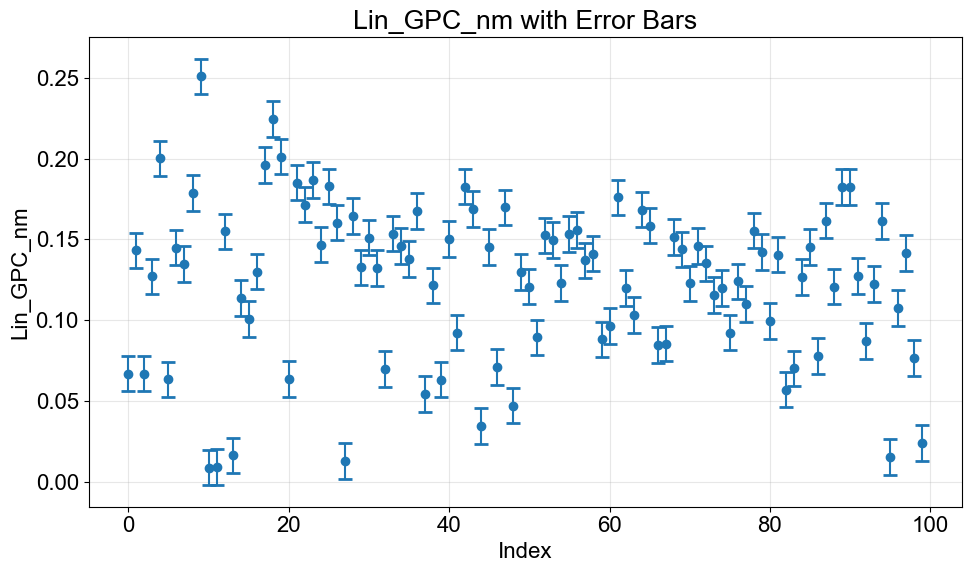

In [5]:
import matplotlib.pyplot as plt

# Create the scatter plot with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(
    range(len(merged_df)),  # x-axis: index
    merged_df['dep_rate_mean'], # refellips_file['Lin_GPC_nm'],  # y-axis
    yerr=merged_df['dep_rate_deviation'] ,  # error bars
    fmt='o',  # marker style (circles)
    capsize=5,  # cap width for error bars
    capthick=2,  # cap thickness
    elinewidth=1.5,  # error bar line width
    markersize=6  # marker size
)

plt.xlabel('Index')
plt.ylabel('Lin_GPC_nm')
plt.title('Lin_GPC_nm with Error Bars')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GP Model Objects

In [ ]:
# ########################################
# # Do you want to re-fit the GP models or just load and reconstruct them?
re_fit_GP_models = False
# ########################################

def load_from_module_path(path):
    m,c = path.split(":")
    mod = importlib.import_module(m)
    C = getattr(mod, c)
    return mod, C

config = campaign['configs'][-1]
parameter_space_limits = []
for param in config['modeled_params']:
    parameter_space_limits.append(config['param_limits'][param])

# Defining the GP model class from the path
_ , GPmodel = load_from_module_path(gp_model_path)

# Fit the GP model for each step in the campaign

# Indices to fit GP models. The first 5 experiments are random in the 4d case
indices_to_process = range(6, len(merged_df))

if re_fit_GP_models:
    # Initialize storage for hyperparameters
    hyperparameters_history = []
    iteration_numbers = []

    for i in indices_to_process:
        print(f"Fitting GP model for run index: {i}")
        current_data = merged_df.iloc[:i+1]
        merged_df.at[i, 'gpmodel'] = GPmodel(current_data, 
                                            input_names=config['modeled_params'], output_name='dep_rate_mean',
                                            parameter_space_limits=parameter_space_limits,
                                            output_deviation_variable='dep_rate_deviation',
                                            #prev_trained_GP_hps=np.array(merged_df.at[i,'current_trained_hps']), # Comment this out if you want to retrain the model
                                            train_method="global",
                                            train_max_iter=4000)
        
        # Get current hyperparameters
        current_hps = merged_df.at[i, 'gpmodel'].current_trained_hps
        #print(current_hps)
        
        # Store hyperparameters and iteration number
        hyperparameters_history.append(current_hps.copy())
        iteration_numbers.append(i)

    # Before saving - store hyperparameters in a new column
    merged_df['gp_hyperparameters'] = None
    for i in indices_to_process:
        if 'gpmodel' in merged_df.columns and pd.notna(merged_df.at[i, 'gpmodel']):
            merged_df.at[i, 'gp_hyperparameters'] = merged_df.at[i, 'gpmodel'].current_trained_hps.copy()

    # Save without gpmodel column
    df_to_save = merged_df.drop(columns=['gpmodel'], errors='ignore')
    df_to_save.to_pickle(f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/merged_df.pkl")

else:
    # Load and reconstruct
    merged_df = pd.read_pickle(f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/merged_df.pkl")
    merged_df['gpmodel'] = None

    for i in merged_df[merged_df['gp_hyperparameters'].notna()].index:
        print(f"Reconstructing GP model for run index: {i}")
        current_data = merged_df.iloc[:i+1]
        merged_df.at[i, 'gpmodel'] = GPmodel(
            current_data, 
            input_names=config['modeled_params'], 
            output_name='dep_rate_mean',
            parameter_space_limits=parameter_space_limits,
            output_deviation_variable='dep_rate_deviation',
            prev_trained_GP_hps=merged_df.at[i, 'gp_hyperparameters'],
            train_method="global",
            train_max_iter=4000
        )


Reconstructing GP model for run index: 6
Reconstructing GP model for run index: 7
Reconstructing GP model for run index: 8
Reconstructing GP model for run index: 9
Reconstructing GP model for run index: 10
Reconstructing GP model for run index: 11
Reconstructing GP model for run index: 12
Reconstructing GP model for run index: 13
Reconstructing GP model for run index: 14
Reconstructing GP model for run index: 15
Reconstructing GP model for run index: 16
Reconstructing GP model for run index: 17
Reconstructing GP model for run index: 18
Reconstructing GP model for run index: 19
Reconstructing GP model for run index: 20
Reconstructing GP model for run index: 21
Reconstructing GP model for run index: 22
Reconstructing GP model for run index: 23
Reconstructing GP model for run index: 24
Reconstructing GP model for run index: 25
Reconstructing GP model for run index: 26
Reconstructing GP model for run index: 27
Reconstructing GP model for run index: 28
Reconstructing GP model for run index:

# RMSE Calculations of all experimental data and Information Gain

In [25]:
# Find experimental data from BO and random campaigns
if campaign_num in ['0009', '0015']:
    campaigns_to_compare = ['0009', '0015']
elif campaign_num in ['0026', '0027']:
    campaigns_to_compare = ['0026', '0027']

all_exp_data_list = []

for campaign_num_current in campaigns_to_compare:

    print(f"Loading campaign {campaign_num_current}...")
    
    # Standard loader handles refellips postprocessing and,
    # for 0015, the first-5-point replacement from 0009.
    merged_df_current, _, _, current_campaign = load_campaign_df(campaign_num_current)

    # Extract the modeled params + dep_rate_mean
    config = current_campaign['configs'][0]
    columns_to_extract = config['modeled_params'] + ['dep_rate_mean']

    current_campaign_data = merged_df_current[columns_to_extract].copy()
    current_campaign_data['campaign'] = campaign_num_current
    all_exp_data_list.append(current_campaign_data)

# SINGLE COMBINED DATAFRAME
all_exp_data = pd.concat(all_exp_data_list, ignore_index=True)
all_exp_data

Loading campaign 0026...
Loading campaign 0027...


,plasma_duration,precursor_dose_time,process_pressure,ALD_purge_time,plasma_pressure,RF_power_setpoint,plasma_prep_time,plasma_purge_time,H2_plasma_flow_rate,Ar_process_flow_rate,ALD_purge_flow_rate,ALD_prep_time,dep_rate_mean,campaign
0,4041,4195,203,2469,125,130,4812,2744,83,82,12,3596,0.079829,0026
1,921,4953,222,1558,96,297,2597,2295,72,68,11,1154,0.069934,0026
2,1295,1586,243,4236,167,275,3124,7432,37,47,15,649,0.000235,0026
3,805,3436,276,3604,143,294,699,930,51,88,12,1770,0.079264,0026
4,4099,4554,37,4206,281,100,2098,5224,92,37,19,238,0.159544,0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,3268,3199,47,3000,275,103,100,4165,55,33,1,1200,0.026700,0027
396,2988,2233,13,2279,223,276,2029,295,42,59,15,2440,0.073650,0027
397,890,2544,111,3654,44,59,3132,5050,39,28,7,723,0.040814,0027
398,3572,4200,27,372,200,191,4522,9026,81,64,7,2254,0.058179,0027


## Old Method, this is not accurate --- Information gain is here.

In [36]:
# recalc_rmse_all_exp = False  # Set to True if you want to recalculate RMSE, False to load from CSV

# # Define CSV filename
# csv_filename = f"campaigns/{campaign['short_name']}/rmse_current_all_exp_info_gain.csv"

# ################################################################
# if len(config['modeled_params'])<5: 
#     # Define the points in space where we want to evaluate the GP models for information gain calculation
#     # Testing data
#     n_test_points_per_dim = 8
#     test_grids = []
#     for i, limit in enumerate(parameter_space_limits):
#         test_grids.append(np.linspace(limit[0], limit[1], n_test_points_per_dim))

#     # Create meshgrid for all 4 dimensions
#     meshes = np.meshgrid(*test_grids, indexing='ij')

#     # Flatten and combine into test points
#     x_test = np.column_stack([mesh.ravel() for mesh in meshes])

#     # Convert to DataFrame
#     x_test_df = pd.DataFrame(x_test, columns=config['modeled_params'])

#     latest_gpmodel = merged_df.at[99, 'gpmodel']

#     x_test_df_normalized = x_test_df.copy()

#     x_test_df_normalized[config['modeled_params']] = latest_gpmodel.scaler.transform(x_test_df[config['modeled_params']])

#     x_test_normalized = np.array(x_test_df_normalized)

# else:
#     x_test_normalized = None
# ################################################################

# def calculate_rmse_with_sem(actual_values, predictions):
#     """
#     Calculate RMSE and its standard error
#     """
#     actual_values = np.array(actual_values).flatten().astype(float)
#     predictions = np.array(predictions).flatten().astype(float)
    
#     # Calculate individual squared errors
#     squared_errors = (actual_values - predictions) ** 2
    
#     # Calculate mean and std of squared errors
#     mean_squared_errors = np.mean(squared_errors)
#     std_squared_errors = np.std(squared_errors, ddof=1)
    
#     # Take square root of both
#     rmse = np.sqrt(mean_squared_errors)
#     root_std = np.sqrt(std_squared_errors)
    
#     # Calculate SEM
#     n = len(squared_errors)
#     sem = root_std / np.sqrt(n)

#     return rmse, sem


# ################################################################

# if recalc_rmse_all_exp:
#     print("🔄 Recalculating RMSE and SEM for all models...")
    
#     # Initialize the columns
#     merged_df['rmse_all_exp'] = None
#     merged_df['rmse_all_exp_sem'] = None
#     merged_df['rmse_current_exp'] = None
#     merged_df['rmse_current_exp_sem'] = None
#     merged_df['information_gain'] = None
    
#     # Check if CSV exists and delete it for a fresh start
#     if os.path.exists(csv_filename):
#         os.remove(csv_filename)
       
#     # Create directory if it doesn't exist
#     os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
    
#     # Calculate RMSE for each model
#     for i in indices_to_process:
        
#         print(f"🔬 Calculating RMSE and SEM for run {i}")
        
#         gpmodel = merged_df.at[i, 'gpmodel']
        
#         ################################################################
#         # RMSE Calculation for all experimental data

#         # Make predictions using the current GP model
#         my_predictions_all_exp, _ = gpmodel.posterior(all_exp_data[config['modeled_params']], predict_cov=False)
        
#         # Get actual experimental values
#         actual_values_all_exp = all_exp_data['dep_rate_mean'].values

#         # ✅ Calculate RMSE and SEM using raw values
#         rmse_all_exp, sem_all_exp = calculate_rmse_with_sem(actual_values_all_exp, my_predictions_all_exp)

#         # Store in dataframe
#         merged_df.at[i, 'rmse_all_exp'] = rmse_all_exp
#         merged_df.at[i, 'rmse_all_exp_sem'] = sem_all_exp
        
#         ################################################################
#         # RMSE Calculation for current experimental data

#         # Make predictions using the current GP model
#         my_predictions_current_exp, _ = gpmodel.posterior(merged_df[config['modeled_params']], predict_cov=False)
        
#         # Get actual experimental values
#         actual_values_current_exp = merged_df['dep_rate_mean'].values

#         # ✅ Calculate RMSE and SEM using raw values
#         rmse_current_exp, sem_current_exp = calculate_rmse_with_sem(actual_values_current_exp, my_predictions_current_exp)

#         # Store in dataframe
#         merged_df.at[i, 'rmse_current_exp'] = rmse_current_exp
#         merged_df.at[i, 'rmse_current_exp_sem'] = sem_current_exp
        
#         ################################################################
#         # Information gain

#         if i > 6 and len(config['modeled_params']) < 5: 
#             prev_gpmodel = merged_df.at[i-1, 'gpmodel']
#             current_gpmodel = merged_df.at[i, 'gpmodel']

#             my_posterior_mean_GP1 = prev_gpmodel.my_gpo.posterior_mean(x_test_normalized)["m(x)"]
#             my_posterior_covariance_GP1 = prev_gpmodel.my_gpo.posterior_covariance(x_test_normalized, add_noise=False)['S'] + 1e-5 * np.eye(len(x_test_normalized))
            
#             my_posterior_mean_GP2 = current_gpmodel.my_gpo.posterior_mean(x_test_normalized)["m(x)"]
#             my_posterior_covariance_GP2 = current_gpmodel.my_gpo.posterior_covariance(x_test_normalized, add_noise=False)['S'] + 1e-5 * np.eye(len(x_test_normalized))
            
#             info_gain = current_gpmodel.my_gpo.posterior.kl_div(my_posterior_mean_GP1, my_posterior_mean_GP2, my_posterior_covariance_GP1, my_posterior_covariance_GP2)

#             merged_df.at[i, 'information_gain'] = info_gain
                            
#         else:
#             # For early runs (i <= 6) OR high-dimensional cases (>= 5 params)
#             merged_df.at[i, 'information_gain'] = np.nan

#         # ✅ Save all results to CSV including SEM - AFTER all calculations are done
#         print("💾 Saving all calculated metrics to CSV...")
#         all_metrics = merged_df[['rmse_all_exp', 'rmse_all_exp_sem', 'rmse_current_exp', 'rmse_current_exp_sem', 'information_gain']].copy()
#         all_metrics.to_csv(csv_filename, index=True)


# else:
#     print("📖 Loading all metrics from CSV...")
    
#     if os.path.exists(csv_filename):
#         all_metrics = pd.read_csv(csv_filename, index_col=0)
        
#         # Add back to merged_df
#         for col in ['rmse_all_exp', 'rmse_all_exp_sem', 'rmse_current_exp', 'rmse_current_exp_sem', 'information_gain']:
#             if col in all_metrics.columns:
#                 merged_df[col] = all_metrics[col]
    
#     print("📖 Loaded")
 

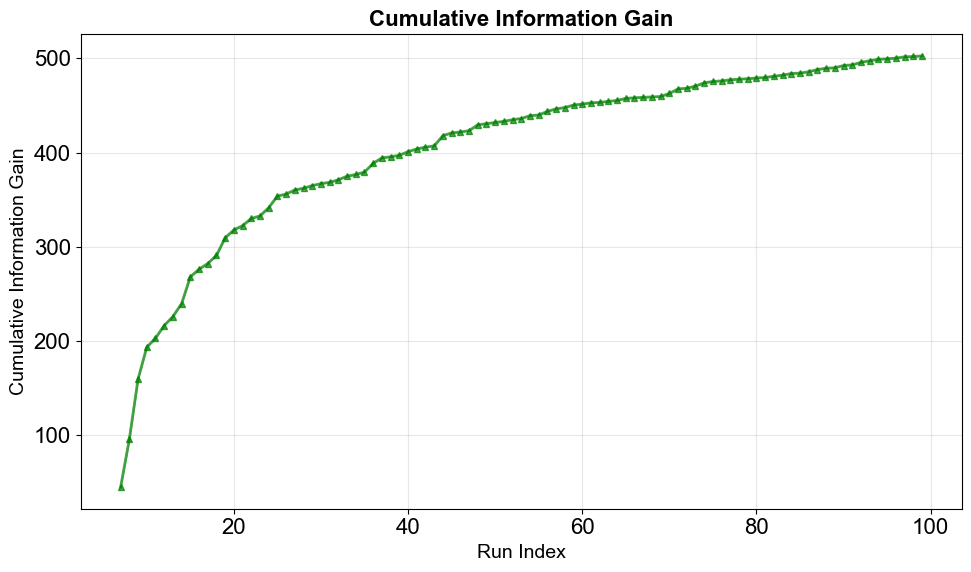

In [9]:

# Load data
csv_filename_combined = f"campaigns/{campaign['short_name']}/rmse_current_all_exp_info_gain.csv"

all_metrics = pd.read_csv(csv_filename_combined, index_col=0)

# # ✅ PLOT 1: RMSE on All Experimental Data with SEM (Separate)
# valid_data = all_metrics['rmse_all_exp'].dropna()
# # Assuming you have SEM columns, if not, set to zeros or calculate from raw data
# valid_sem = all_metrics['rmse_all_exp_sem'].dropna() if 'rmse_all_exp_sem' in all_metrics.columns else np.zeros(len(valid_data))

# plt.figure(figsize=(10, 6))
# plt.plot(valid_data.index, valid_data.values, 
#         'b-o', linewidth=2, markersize=5, alpha=0.7)

# # Add shaded region for standard error
# plt.fill_between(valid_data.index, 
#                 valid_data.values - valid_sem.values, 
#                 valid_data.values + valid_sem.values, 
#                 alpha=0.2, color='blue')

# plt.title('RMSE on All Experimental Data', fontsize=16, fontweight='bold')
# plt.xlabel('Run Index', fontsize=14)
# plt.ylabel('RMSE', fontsize=14)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()

# # Save plot
# plot1_filename = f"Plots/{campaign['short_name']}/rmse_all_exp.png"
# plt.savefig(plot1_filename, dpi=300, bbox_inches='tight')

# plt.show()

#############################################################################
# # ✅ PLOT 2: RMSE on Current Experimental Data with SEM (Separate)
# valid_data = all_metrics['rmse_current_exp'].dropna()
# valid_sem = all_metrics['rmse_current_exp_sem'].dropna() if 'rmse_current_exp_sem' in all_metrics.columns else np.zeros(len(valid_data))

# plt.figure(figsize=(10, 6))
# plt.plot(valid_data.index, valid_data.values, 
#          'r-s', linewidth=2, markersize=5, alpha=0.7)

# # Add shaded region for standard error
# plt.fill_between(valid_data.index, 
#                  valid_data.values - valid_sem.values, 
#                  valid_data.values + valid_sem.values, 
#                  alpha=0.2, color='red')

# plt.title('RMSE on Current Experimental Data', fontsize=16, fontweight='bold')
# plt.xlabel('Run Index', fontsize=14)
# plt.ylabel('RMSE', fontsize=14)
# plt.grid(True, alpha=0.3)
    
# plt.tight_layout()

# # Save plot
# plot2_filename = f"Plots/{campaign['short_name']}/rmse_current_exp.png"
# plt.savefig(plot2_filename, dpi=300, bbox_inches='tight')

# plt.show()
#############################################################################

# ✅ PLOT 3: Cumulative Information Gain with SEM (Separate)
valid_data = all_metrics['information_gain'].dropna()
valid_sem = all_metrics['information_gain_sem'].dropna() if 'information_gain_sem' in all_metrics.columns else np.zeros(len(valid_data))

if len(valid_data) > 0:
    # Calculate cumulative sum
    cumulative_info_gain = valid_data.cumsum()
    # For cumulative SEM, you might want to propagate errors differently
    cumulative_sem = np.sqrt(np.cumsum(np.asarray(valid_sem)**2))  # Fixed: using np.asarray()
    
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_info_gain.index, cumulative_info_gain.values, 
            'g-^', linewidth=2, markersize=5, alpha=0.7)
    
    # Add shaded region for standard error
    plt.fill_between(cumulative_info_gain.index, 
                    cumulative_info_gain.values - cumulative_sem, 
                    cumulative_info_gain.values + cumulative_sem, 
                    alpha=0.2, color='green')
    
    plt.title('Cumulative Information Gain', fontsize=16, fontweight='bold')
    plt.xlabel('Run Index', fontsize=14)
    plt.ylabel('Cumulative Information Gain', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    plot3_filename = f"Plots/{campaign['short_name']}/cumulative_info_gain.png"
    # plt.savefig(plot3_filename, dpi=300, bbox_inches='tight')
    
    plt.show()

✅ Loaded Campaign 0009: (100, 5)
✅ Loaded Campaign 0015: (100, 5)


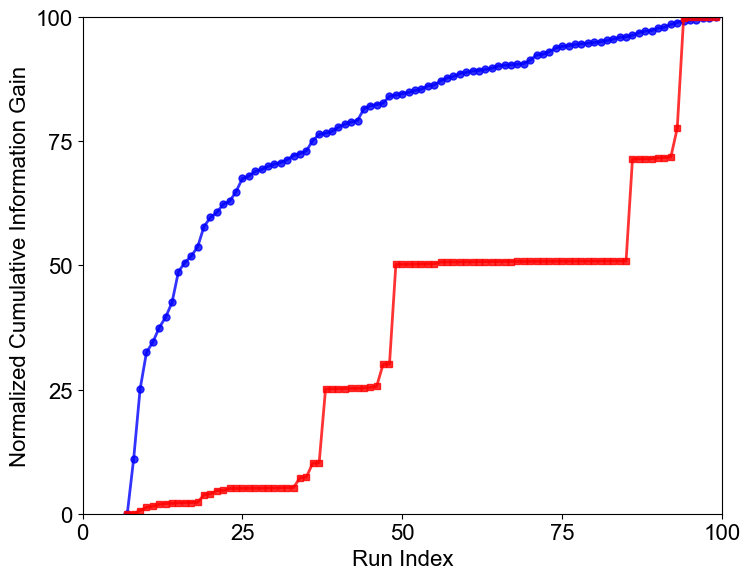

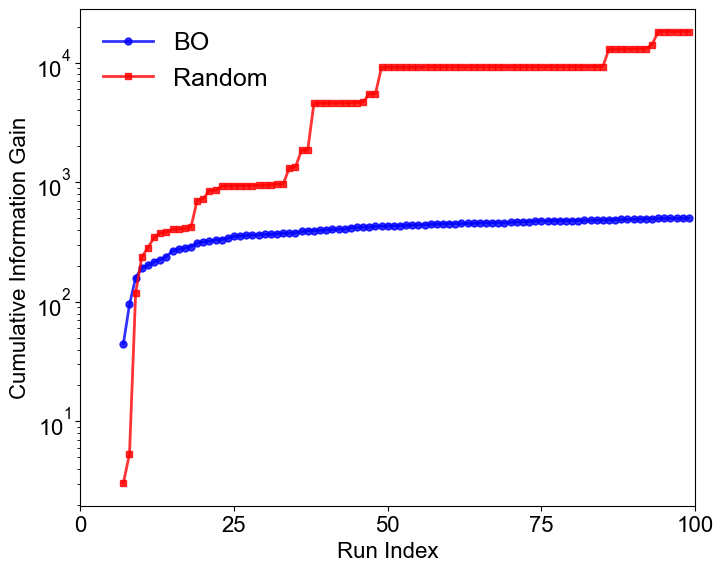

In [20]:
Replot_RMSE_INfo = True

if Replot_RMSE_INfo:
        
    # Plotting two campaigns together for comparison with error bars

    # ✅ LOAD DATA FOR BOTH CAMPAIGNS
    campaign_data = {}
    #campaign_labels = {'0015': 'Random', '0009': 'BO', '0018': 'Random', '0019': 'BO'}
    campaign_labels = {'0015': 'Random', '0009': 'BO', '0027': 'Random', '0026': 'BO'}

    for campaign_num_current in campaigns_to_compare:
        # Find campaign directory
        campaign_dir = None
        for dirname in os.listdir("campaigns"):
            if f"campaign{campaign_num_current}" in dirname:
                campaign_dir = dirname
                break
        
        if campaign_dir:
            csv_file = f"campaigns/{campaign_dir}/rmse_current_all_exp_info_gain.csv"
            if os.path.exists(csv_file):
                campaign_data[campaign_num_current] = pd.read_csv(csv_file, index_col=0)
                print(f"✅ Loaded Campaign {campaign_num_current}: {campaign_data[campaign_num_current].shape}")

    # # ✅ PLOT 1: RMSE on All Experimental Data with Error Bars
    # plt.figure(figsize=(7.7, 6))

    colors = ['blue', 'red']
    markers = ['o', 's']

    # for i, campaign_num_current in enumerate(campaigns_to_compare):
    #     if campaign_num_current in campaign_data:
    #         data = campaign_data[campaign_num_current]
            
    #         if 'rmse_all_exp' in data.columns:
    #             rmse_data = data['rmse_all_exp'].dropna()
                
    #             # Plot main line
    #             plt.plot(rmse_data.index, rmse_data.values, 
    #                     color=colors[i], marker=markers[i], linewidth=2, markersize=5, 
    #                     alpha=0.8, label=f'Mean RMSE ({campaign_labels[campaign_num_current]})')#label=f'Campaign {campaign_num_current} ({campaign_labels[campaign_num_current]})')
                
    #             # ✅ Add shaded region for SEM if available
    #             if 'rmse_all_exp_sem' in data.columns:
    #                 sem_data = data.loc[rmse_data.index, 'rmse_all_exp_sem']
                    
    #                 plt.fill_between(rmse_data.index, 
    #                             rmse_data.values - sem_data.values, 
    #                             rmse_data.values + sem_data.values, 
    #                             color=colors[i], alpha=0.3,
    #                                 label = "Standard error")

    # #plt.title('RMSE on All Experimental Data - Campaign Comparison', fontsize=16, fontweight='bold')
    # plt.xlabel('Run Index', fontsize=16)
    # plt.ylabel('RMSE', fontsize=16)
    # #plt.grid(True, alpha=0.3)

    # plt.tight_layout()
    # #plt.ylim(0.02, 0.07)
    # #plt.xlim(0, 100)

    # if campaign_num == "0009":
    #     plt.ylim(0.017, 0.05)
    #     plt.xticks([5,25,50,75,100])
    #     plt.xlim(5,100)

    # else:
    #     plt.ylim(0.018, 0.06)
    #     plt.xlim(5, 200)
    #     plt.xticks([5,50,100, 150,200])


    # # plt.tick_params(axis="y", direction="in")
    # # plt.tick_params(axis="x", direction="in")
    # # plt.tick_params(top=True, right=True)
    # plt.locator_params(axis='y', nbins=5)

    # # reordering the labels
    # handles, labels = plt.gca().get_legend_handles_labels()

    # # specify order
    # order = [2,3,0,1]

    # # pass handle & labels lists along with order as below
    # plt.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=12,frameon=False)


    # plot1_file = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.png"
    # # plot1_file = f"G:/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.png"
    # plt.savefig(plot1_file, dpi=300, bbox_inches='tight')

    # plot1_file_pdf = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.pdf"
    # # plot1_file_pdf = f"G:/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.pdf"
    # plt.savefig(plot1_file_pdf, dpi=300, bbox_inches='tight')

    # plt.show()

    #############################################################################
    # ✅ PLOT 2: RMSE on Current Experimental Data with Error Bars
    # plt.figure(figsize=(12, 7))

    # for i, campaign_num_current in enumerate(campaigns_to_compare):
    #     if campaign_num_current in campaign_data:
    #         data = campaign_data[campaign_num_current]
            
    #         if 'rmse_current_exp' in data.columns:
    #             rmse_data = data['rmse_current_exp'].dropna()
                
    #             # Plot main line
    #             plt.plot(rmse_data.index, rmse_data.values, 
    #                     color=colors[i], marker=markers[i], linewidth=2, markersize=5, 
    #                     alpha=0.8, label=f'Mean RMSE ({campaign_labels[campaign_num_current]})')#label=f'Campaign {campaign_num_current} ({campaign_labels[campaign_num_current]})')
                
    #             # ✅ Add shaded region for SEM if available
    #             if 'rmse_current_exp_sem' in data.columns:
    #                 sem_data = data.loc[rmse_data.index, 'rmse_current_exp_sem']
                    
    #                 plt.fill_between(rmse_data.index, 
    #                                rmse_data.values - sem_data.values, 
    #                                rmse_data.values + sem_data.values, 
    #                                color=colors[i], alpha=0.3)

    # #plt.title('RMSE on Current Experimental Data - Campaign Comparison', fontsize=16, fontweight='bold')
    # plt.xlabel('Run Index', fontsize=14)
    # plt.ylabel('RMSE', fontsize=14)
    # plt.grid(True, alpha=0.3)
    # plt.legend(fontsize=12)
    # plt.tight_layout()

    # #plot2_file = f"campaigns/comparison_rmse_current_exp_{'_vs_'.join(campaigns_to_compare)}.png"
    # #plt.savefig(plot2_file, dpi=300, bbox_inches='tight')
    # plt.show()

    #############################################################################

    # ✅ PLOT 3: Cumulative Normalized Information Gain

    if campaign_num in ['0009', '0015']:
        
        plt.figure(figsize=(7.6, 6))

        for i, campaign_num_current in enumerate(campaigns_to_compare):
            if campaign_num_current in campaign_data and 'information_gain' in campaign_data[campaign_num_current].columns:
                data = campaign_data[campaign_num_current]['information_gain'].dropna()
                if len(data) > 0:
                    cumulative_data = data.cumsum()
                    
                    # Normalize from 0 to 1
                    min_val = cumulative_data.min()
                    max_val = cumulative_data.max()
                    normalized_data = 100*  (cumulative_data - min_val) / (max_val - min_val)
                    
                    plt.plot(cumulative_data.index, normalized_data.values, 
                            color=colors[i], marker=markers[i], linewidth=2, markersize=5, 
                            alpha=0.8, label=f'{campaign_labels[campaign_num_current]}')

        #plt.title('Cumulative Information Gain - Campaign Comparison (Normalized)', fontsize=16, fontweight='bold')
        plt.xlabel('Run Index', fontsize=16)
        plt.ylabel('Normalized Cumulative Information Gain', fontsize=16)
        #plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.ylim(0, 1)
        plt.xlim(0, 100)
        plt.xticks([0,25,50,75,100])
        plt.yticks([0,25,50,75,100])
     


        # plot3_file = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_cumulative_info_gain_{'_vs_'.join(campaigns_to_compare)}.png"
        # plt.savefig(plot3_file, dpi=300, bbox_inches='tight')

        # plot3_file_pdf = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_cumulative_info_gain_{'_vs_'.join(campaigns_to_compare)}.pdf"
        # plt.savefig(plot3_file_pdf, dpi=300, bbox_inches='tight')

        plt.show()

    # ✅ PLOT 4: Cumulative Information Gain

    if campaign_num in ['0009', '0015']:
        
        plt.figure(figsize=(7.6, 6))

        for i, campaign_num_current in enumerate(campaigns_to_compare):
            if campaign_num_current in campaign_data and 'information_gain' in campaign_data[campaign_num_current].columns:
                data = campaign_data[campaign_num_current]['information_gain'].dropna()
                if len(data) > 0:
                    cumulative_data = data.cumsum()
                    
                    # Normalize from 0 to 1
                    min_val = cumulative_data.min()
                    max_val = cumulative_data.max()
                    
                    plt.plot(cumulative_data.index, cumulative_data.values, 
                            color=colors[i], marker=markers[i], linewidth=2, markersize=5, 
                            alpha=0.8, label=f'{campaign_labels[campaign_num_current]}')

        #plt.title('Cumulative Information Gain - Campaign Comparison (Normalized)', fontsize=16, fontweight='bold')
        plt.xlabel('Run Index', fontsize=16)
        plt.ylabel('Cumulative Information Gain', fontsize=16)
        #plt.grid(True, alpha=0.3)
        plt.tight_layout()
        # plt.ylim(0, 1)
        plt.xlim(0, 100)
        plt.xticks([0,25,50,75,100])
        # plt.yticks([0,25,50,75,100])
        plt.yscale('log')
        # plot3_file = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_Unnormalized_cumulative_info_gain_{'_vs_'.join(campaigns_to_compare)}.png"
        # plt.savefig(plot3_file, dpi=300, bbox_inches='tight')
        plt.legend(fontsize=18, loc='upper left',frameon=False)

        plot3_file_pdf = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_Unnormalized_cumulative_info_gain_{'_vs_'.join(campaigns_to_compare)}.pdf"
        plt.savefig(plot3_file_pdf, dpi=300, bbox_inches='tight')

        plt.show()


    else:
        print("Cumulative Information Gain plot is only for campaigns 0009 and 0015.")


In [39]:
# # Plotting the infromation gain of campaign 9

# csv_file = "campaigns/250730_TDMAT_campaign0009/rmse_current_all_exp_info_gain.csv"

# camp_9_rmse_info = pd.read_csv(csv_file, index_col=0)

# # Drop missing values in information_gain
# ig = camp_9_rmse_info['information_gain'].dropna()

# # Compute cumulative sum
# cumulative_ig = ig.cumsum()

# # Find where each new point contributes less than 1% of the current cumulative sum
# # i.e. where ig[i] / cumulative_ig[i] < 0.01
# contribution = ig / cumulative_ig.shift(1)
# threshold = 0.001
# cutoff_idx = contribution[contribution < threshold].index[0]  # first point below 1%


# # Plot
# fig, ax1 = plt.subplots(figsize=(8, 5))

# ax1.plot(cumulative_ig.index, cumulative_ig.values, color='steelblue', label='Cumulative Information Gain')
# ax1.axvline(x=cutoff_idx, color='red', linestyle='--', label=f'<1% contribution (exp {cutoff_idx})')
# ax1.set_xlabel('Experiment Index')
# ax1.set_ylabel('Cumulative Information Gain', color='steelblue')
# ax1.tick_params(axis='y', labelcolor='steelblue')

# # Overlay the contribution percentage on a second axis
# ax2 = ax1.twinx()
# ax2.plot(contribution.index, contribution.values * 100, color='orange', alpha=0.6, label='Contribution (%)')
# ax2.axhline(y=1, color='orange', linestyle=':', alpha=0.8, label='1% threshold')
# ax2.set_ylabel('Contribution to Cumulative IG (%)', color='orange')
# ax2.tick_params(axis='y', labelcolor='orange')

# # Combine legends
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# plt.title('Cumulative Information Gain — Campaign 9')
# plt.tight_layout()
# plt.show()

# print(f"Information gain contribution drops below 1% at experiment index: {cutoff_idx}")


## Computing RMSE the correct way

In [40]:
# Randomly sample 100 sets of 50 points from the pool of experimental data, excluding the first 5 (4d) points of each campaign

resample_sets = True  # Set to True if you want to recalculate RMSE, False to load from JSON

N_SETS = 100
SET_SIZE = 50
SEED = 42

if campaign_num in ['0009', '0015']:
    N_drop_rows_per_campaign = 5  # Number of rows to drop from each campaign
    prob_dimensionality = 4
elif campaign_num in ['0026', '0027','0018','0019']:
    N_drop_rows_per_campaign = 15  # Number of rows to drop from each campaign
    prob_dimensionality = 12

OUT_PATH = Path(f"RMSE_heldout_sets_{prob_dimensionality}d.json")

# Find experimental data from BO and random campaigns
if campaign_num in ['0009', '0015']:
    campaigns_to_compare = ['0009', '0015']
elif campaign_num in ['0026', '0027']:
    campaigns_to_compare = ['0026', '0027']


if resample_sets:

    
    all_exp_data_list = []

    for campaign_num_current in campaigns_to_compare:

        print(f"Loading campaign {campaign_num_current}...")
        
        # Standard loader handles refellips postprocessing and,
        # for 0015, the first-5-point replacement from 0009.
        merged_df_current, _, _, current_campaign = load_campaign_df(campaign_num_current)

        # Extract the modeled params + dep_rate_mean
        config = current_campaign['configs'][0]
        columns_to_extract = config['modeled_params'] + ['dep_rate_mean']

        current_campaign_data = merged_df_current[columns_to_extract].copy()
        current_campaign_data['campaign'] = campaign_num_current
        all_exp_data_list.append(current_campaign_data)

    # SINGLE COMBINED DATAFRAME
    all_exp_data = pd.concat(all_exp_data_list, ignore_index=True)
    print("all_exp_data: ", len(all_exp_data))

    print(f"Resampling {N_SETS} sets of {SET_SIZE} points, excluding first {N_drop_rows_per_campaign} per campaign...")
    feature_cols = [c for c in all_exp_data.columns if c != 'campaign']

    pool_parts = []
    for camp, grp in all_exp_data.groupby('campaign', sort=False):
        pool_parts.append(grp.iloc[N_drop_rows_per_campaign:])
    pool = pd.concat(pool_parts, ignore_index=True)

    print(f"Total rows: {len(all_exp_data)}, pool after dropping first-{N_drop_rows_per_campaign} per campaign: {len(pool)}")

    def generate_sets():
        rng = np.random.default_rng(SEED)
        sets = []
        set_campaigns = []                      # NEW: parallel campaign labels
        pool_campaigns = pool['campaign'].to_numpy()   # campaign of every pool row
        for _ in range(N_SETS):
            idx = rng.choice(len(pool), size=SET_SIZE, replace=False)
            sets.append(pool.iloc[idx][feature_cols].to_numpy().tolist())
            set_campaigns.append(pool_campaigns[idx].tolist())   # NEW
        return sets, set_campaigns

    sampled_sets, sampled_set_campaigns = generate_sets()

    # ---- diagnostic: how many points per campaign in each set ----
    from collections import Counter

    counts_per_set = [Counter(c) for c in sampled_set_campaigns]
    camps = sorted(pool['campaign'].unique())
    

    payload = {"columns": feature_cols, "sets": sampled_sets}
    with open(OUT_PATH, "w") as f:
        json.dump(payload, f)
    

else:
    with open(OUT_PATH) as f:
        payload = json.load(f)
    feature_cols = payload["columns"]        # <-- recover names
    sampled_sets = payload["sets"]
    print(f"Loaded {len(sampled_sets)} sets from {OUT_PATH}")

Loading campaign 0026...
Loading campaign 0027...
all_exp_data:  400
Resampling 100 sets of 50 points, excluding first 15 per campaign...
Total rows: 400, pool after dropping first-15 per campaign: 370


In [16]:
def _crps_s(x, mu, sigma):
        res = abs(sigma * ((1. / np.sqrt(np.pi))
                           - 2. * norm.pdf((x - mu) / sigma)
                           - (((x - mu) / sigma) * (2. * norm.cdf((x - mu) / sigma) - 1.))))
        return np.mean(res), np.sqrt(np.var(res))

def crps(my_predictions_test, my_ucertainty_test,actual_values_test):

    """
    This function calculates the continuous rank probability score.

    Parameters
    ----------
    x_test : np.ndarray
        A numpy array of shape (V x D), interpreted as  an array of input point positions.
    y_test : np.ndarray
        A numpy array of shape (V x No) in the multi-output case. These are the y data to compare against.

    Returns
    -------
    CRPS, standard dev. of CRPS : (float, float)
    """

    mean = my_predictions_test
    sigma = my_ucertainty_test
    y_test = actual_values_test

    assert mean.shape == sigma.shape == y_test.shape, \
        f"crps: shape mismatch mean={mean.shape} sigma={sigma.shape} y_test={y_test.shape}"
    r = _crps_s(y_test, mean, sigma)
    return r



def nlpd(my_predictions_test, my_ucertainty_test,actual_values_test):  # correct, tested
        """
        This function calculates the Negative log predictive density.

        Parameters
        ----------
        x_test : np.ndarray
            A numpy array of shape (V x D), interpreted as  an array of input point positions.
        y_test : np.ndarray
            A numpy array of shape V or (V x No) in the multi-output case. These are the y data to compare against.

        Returns
        -------
        NLPD : float
        """

        mean = my_predictions_test
        v = my_ucertainty_test**2
        y_test = actual_values_test

        assert mean.shape == v.shape == y_test.shape, \
            f"nlpd: shape mismatch mean={mean.shape} v={v.shape} y_test={y_test.shape}"

        term1 = 0.5 * np.log(2 * np.pi * v)
        term2 = 0.5 * ((y_test - mean) ** 2) / v
        nlpd = np.mean(term1 + term2)
        return nlpd



def r2(my_predictions_test, actual_values_test):
    """
    This function calculates the R2 prediction score.

    Parameters
    ----------
    x_test : np.ndarray
        A numpy array of shape (V x D), interpreted as  an array of input point positions.
    y_test : np.ndarray
        A numpy array of shape V or (V x No) in the multi-output case. These are the y data to compare against.

    Returns
    -------
    R2 : float
    """
    y_pred_mean = my_predictions_test
    y_test = actual_values_test
    assert y_pred_mean.shape == y_test.shape, \
        f"r2: y_test shape {y_test.shape} != posterior mean shape {y_pred_mean.shape}"
    ss_res = np.sum((y_test - y_pred_mean) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    return 1. - ss_res / ss_tot



def picp(my_predictions_test, my_noisy_ucertainty_test,actual_values_test, interval=0.95):
    """
    Computes the Prediction Interval Coverage Probability (PICP)
    for a Gaussian Process posterior.

    Parameters
    ----------
    x_test : array-like, shape (N,dim)
    y_true : array-like, shape (N,)
        True values of the target variable.
    interval : float, optional
        Confidence interval (default 0.95 for 95% intervals).

    Returns
    -------
    picp : float
        Prediction Interval Coverage Probability
    lower_bounds : ndarray
        Lower bounds of prediction intervals
    upper_bounds : ndarray
        Upper bounds of prediction intervals
    """
    mu = my_predictions_test
    sigma = my_noisy_ucertainty_test

    z = norm.ppf(1 - (1 - interval) / 2)
    lower_bounds = mu - z * sigma
    upper_bounds = mu + z * sigma

    inside = (actual_values_test >= lower_bounds) & (actual_values_test <= upper_bounds)
    picp = np.mean(inside)

    return picp

def mpiw(my_noisy_ucertainty_test, interval=0.95):
        """
        This function calculates the Mean Prediction Interval Width (MPIW).
        It measures the average width of the posterior credible intervals and
        is best interpreted alongside :py:meth:`picp`: a narrow interval with
        high coverage indicates a well-calibrated, sharp model.

        Parameters
        ----------
        x_test : np.ndarray
            A numpy array of shape (V x D), interpreted as an array of input point positions.
        interval : float, optional
            Credible interval level. Default = 0.95.

        Returns
        -------
        MPIW : float
        """
        sigma = np.clip(my_noisy_ucertainty_test, 0.0, None)
        z = norm.ppf(1 - (1 - interval) / 2)
        return np.mean(2 * z * sigma)



def interval_score(my_predictions_test, my_noisy_ucertainty_test,actual_values_test, interval=0.95):
    """
    This function calculates the Interval Score (also known as the Winkler Score).
    It penalizes both missed coverage and unnecessarily wide prediction intervals,
    combining the concerns of :py:meth:`picp` and :py:meth:`mpiw` into a single
    scalar. Lower is better.

    Parameters
    ----------
    x_test : np.ndarray
        A numpy array of shape (V x D), interpreted as an array of input point positions.
    y_test : np.ndarray
        A numpy array of shape V or (V x No) in the multi-output case. These are the y data to compare against.
    interval : float, optional
        Credible interval level. Default = 0.95.

    Returns
    -------
    Interval Score : float
    """
    mean = my_predictions_test
    sigma = my_noisy_ucertainty_test
    y_test = actual_values_test

    assert mean.shape == sigma.shape == y_test.shape, \
        f"interval_score: shape mismatch mean={mean.shape} sigma={sigma.shape} y_test={y_test.shape}"

    alpha = 1 - interval
    z = norm.ppf(1 - alpha / 2)
    lower = mean - z * sigma
    upper = mean + z * sigma
    width = upper - lower
    penalty_low = (2 / alpha) * np.maximum(lower - y_test, 0)
    penalty_high = (2 / alpha) * np.maximum(y_test - upper, 0)
    return np.mean(width + penalty_low + penalty_high)


In [ ]:
import random


# The method followed:
#       Out of 200 points, randomly sample 50, and train models and to predict those. Do that for all iterations of active learning (and random)
#       If the training data happened to include test data, remove it from the training data. This is to avoid data leakage and ensure that the model is evaluated on unseen data.
#       To ensure statistical significance, repeat the process 30 times and average the results. This will give a more robust estimate of the model's performance on unseen data.

n_trials = 100

RMSE_OUT_PATH = Path(f"campaigns/{campaign['short_name']}/RMSE_heldout_sets_correctmethod.json")

def load_results():
    if RMSE_OUT_PATH.exists():
        with open(RMSE_OUT_PATH) as f:
            return json.load(f)
    return {"columns": feature_cols, "trials": {}}   # dict keyed by trial index

def save_results(results):
    tmp = RMSE_OUT_PATH.with_suffix(".tmp")
    with open(tmp, "w") as f:
        json.dump(results, f)
    tmp.replace(RMSE_OUT_PATH)   # atomic-ish: avoids corrupting the file if interrupted mid-write

    
if campaign_num in ['0009', '0015']:
    initial_points = 5
elif campaign_num in ['0026', '0027','0018','0019']:
    initial_points = 15

results = load_results()



# This is the main loop for the trials. Each trial will fit GP models, compute RMSE and store it.
for trial in range(n_trials):
    
    # --- resume: skip trials already saved ---
    if str(trial) in results["trials"]:
        print(f"Trial {trial} already done, skipping.")
        continue

    print(f"Starting trial {trial+1}/{n_trials}")
    
    # Identify the testing set for this trial
    testing_set_df = pd.DataFrame(sampled_sets[trial], columns=feature_cols)

    #--------- Identify which columns in the testing_set_df are in merged_df, we dont want those ---------
    # columns that uniquely identify a row (features + target, matching what you sampled)
    match_cols = feature_cols  # same columns used to build sampled_sets

    # round for safe float comparison
    def _key(df): return df[match_cols].round(9).apply(tuple, axis=1)

    test_keys = set(_key(testing_set_df))
    is_test_row = _key(merged_df).isin(test_keys)   # boolean Series aligned to merged_df
    print(f"Test rows found in merged_df: {is_test_row.sum()}")

    # ------------------ Fit GP models and compute RMSE for each run index --------------------------------
    trial_records = []

    for i in range(initial_points, len(merged_df)+1):
        
        if i % 50 == 0:
            print(f"Trial {trial+1}/{n_trials}, run index {i}/{len(merged_df)}")

        # print(f"Fitting GP model for run index: {i}")

        current_data = merged_df.iloc[:i]
        current_data = current_data[~is_test_row.iloc[:i].values]   # drop test rows

        # Deterministic, unique seed per (trial, run index): reproducible but not degenerate
        seed = 434 + trial * 100000 + i
        random.seed(seed)
        np.random.seed(seed)



        current_gp = GPmodel(current_data,
                            input_names=config['modeled_params'], output_name='dep_rate_mean',
                            parameter_space_limits=parameter_space_limits,
                            output_deviation_variable='dep_rate_deviation',
                            train_method="mcmc",
                            train_max_iter=20000)


        # Compute RMSE for the current GP model on the testing set
        my_predictions_test, my_noisy_ucertainty_test = current_gp.posterior(testing_set_df[config['modeled_params']],cov_add_noise=True)
        _                  , my_ucertainty_test = current_gp.posterior(testing_set_df[config['modeled_params']],predict_mean = False, cov_add_noise=False)
        
        actual_values_test = testing_set_df['dep_rate_mean'].values

        #################################################################################
        # Prediction Error Metrics

        # ----- RMSE -----
        rmse_val = np.sqrt(np.mean((my_predictions_test - actual_values_test) ** 2))

        # ----- R2 -----
        r2_val = r2(my_predictions_test, actual_values_test)

        # ----- CRPS (returns (mean, std)) -----
        crps_val, crps_std = crps(my_predictions_test, my_ucertainty_test, actual_values_test)

        # ----- NLPD -----
        nlpd_val = nlpd(my_predictions_test, my_ucertainty_test, actual_values_test)

        # ----- PICP -----
        picp_val = picp(my_predictions_test, my_noisy_ucertainty_test, actual_values_test)

        # ----- MPIW -----
        mpiw_val = mpiw(my_noisy_ucertainty_test, interval=0.95)

        # ----- Interval Score -----
        interval_score_val = interval_score(my_predictions_test, my_noisy_ucertainty_test,
                                            actual_values_test, interval=0.95)

        trial_records.append({
            "run_index": int(i),
            "n_train": int(len(current_data)),
            "rmse": float(rmse_val),
            "r2": float(r2_val),
            "crps": float(crps_val),
            "crps_std": float(crps_std),
            "nlpd": float(nlpd_val),
            "picp": float(picp_val),
            "mpiw": float(mpiw_val),
            "interval_score": float(interval_score_val),
        })

    results["trials"][str(trial)] = trial_records
    save_results(results)                          # <-- live update after each trial
    print(f"Saved trial {trial}, {len(trial_records)} steps.")


# 27 R: 12,10,12,12,8 ,11,8 ,9 ,11,9
# 26 B: 8, 10,8 ,8 ,12,9 ,12,11,9 ,11 

Starting trial 1/100
Test rows found in merged_df: 27
Trial 1/100, run index 50/200
Trial 1/100, run index 100/200
Trial 1/100, run index 150/200
Trial 1/100, run index 200/200
Saved trial 0, 186 steps.
Starting trial 2/100
Test rows found in merged_df: 27
Trial 2/100, run index 50/200
Trial 2/100, run index 100/200
Trial 2/100, run index 150/200
Trial 2/100, run index 200/200
Saved trial 1, 186 steps.
Starting trial 3/100
Test rows found in merged_df: 25
Trial 3/100, run index 50/200
Trial 3/100, run index 100/200
Trial 3/100, run index 150/200
Trial 3/100, run index 200/200
Saved trial 2, 186 steps.
Starting trial 4/100
Test rows found in merged_df: 26
Trial 4/100, run index 50/200
Trial 4/100, run index 100/200
Trial 4/100, run index 150/200
Trial 4/100, run index 200/200
Saved trial 3, 186 steps.
Starting trial 5/100
Test rows found in merged_df: 22
Trial 5/100, run index 50/200
Trial 5/100, run index 100/200
Trial 5/100, run index 150/200
Trial 5/100, run index 200/200
Saved trial

  campaign_dir found: 260317_TDMAT_campaign0026
    using 100 of 100 trials
    removed 108 outliers (IQR k=1.5)
✅ Loaded Campaign 0026: 100 trials, 186 run indices
  campaign_dir found: 260318_TDMAT_campaign0027
    using 100 of 100 trials
    removed 102 outliers (IQR k=1.5)
✅ Loaded Campaign 0027: 100 trials, 186 run indices


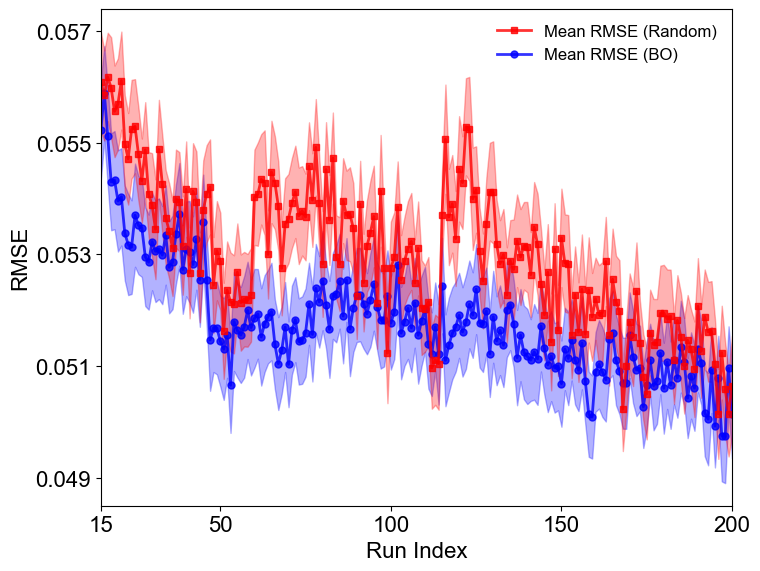

In [73]:
Replot_RMSE_Info = True

if Replot_RMSE_Info:

    # ✅ LOAD DATA FOR BOTH CAMPAIGNS (from new per-trial JSON)
    campaign_data = {}   # campaign_num -> DataFrame indexed by run_index with columns: mean, sem
    campaign_labels = {'0015': 'Random', '0009': 'BO', '0027': 'Random',
                       '0026': 'BO', '0018': 'Random', '0019': 'BO'}

    for campaign_num_current in campaigns_to_compare:

        campaign_dir = None
        for dirname in os.listdir("campaigns"):
            if f"campaign{campaign_num_current}" in dirname:
                campaign_dir = dirname
                break

        print(f"  campaign_dir found: {campaign_dir}")

        if campaign_dir:
            json_file = f"campaigns/{campaign_dir}/RMSE_heldout_sets_correctmethod.json"

            if os.path.exists(json_file):
                with open(json_file) as f:
                    results = json.load(f)

                trials = results["trials"]

                # --- limit to first N_TRIALS trials per campaign ---
                trial_keys = list(trials.keys())
                selected_keys = trial_keys

                print(f"    using {len(selected_keys)} of {len(trial_keys)} trials")

                # Collect rmse per run_index across the selected trials only
                per_index = {}   # run_index -> list of rmse
                for k in selected_keys:
                    for r in trials[k]:
                        per_index.setdefault(r["run_index"], []).append(r["rmse"])
                
                ######################################################################
                # --- outlier removal per run_index (IQR method) ---
                REMOVE_OUTLIERS = True
                IQR_K = 1.5   # 1.5 = standard, 3.0 = only extreme outliers

                def remove_outliers_iqr(vals, k=IQR_K):
                    vals = np.asarray(vals, dtype=float)
                    vals = vals[~np.isnan(vals)]
                    if len(vals) < 4:          # too few points to define quartiles reliably
                        return vals
                    q1, q3 = np.percentile(vals, [25, 75])
                    iqr = q3 - q1
                    lo, hi = q1 - k * iqr, q3 + k * iqr
                    return vals[(vals >= lo) & (vals <= hi)]

                if REMOVE_OUTLIERS:
                    n_removed_total = 0
                    for x in per_index:
                        before = len(per_index[x])
                        per_index[x] = list(remove_outliers_iqr(per_index[x]))
                        n_removed_total += before - len(per_index[x])
                    print(f"    removed {n_removed_total} outliers (IQR k={IQR_K})")

                ######################################################################
                # Gaussian filtering
                APPLY_GAUSSIAN = False
                GAUSSIAN_SIGMA = 2.0   # larger = smoother

                from scipy.ndimage import gaussian_filter1d

                if APPLY_GAUSSIAN:
                    run_idx = sorted(per_index.keys())
                    means_raw = np.array([np.mean(per_index[x]) for x in run_idx])
                    sems_raw = np.array([np.std(per_index[x], ddof=1) / np.sqrt(len(per_index[x]))
                                         if len(per_index[x]) > 1 else 0.0
                                         for x in run_idx])

                    means_smooth = gaussian_filter1d(means_raw, sigma=GAUSSIAN_SIGMA, mode='nearest')
                    sems_smooth = gaussian_filter1d(sems_raw, sigma=GAUSSIAN_SIGMA,mode='nearest')

                    # write back into per_index-derived arrays used below
                    means = means_smooth
                    sems = sems_smooth
                    print(f"    applied Gaussian filter (sigma={GAUSSIAN_SIGMA})")
                else:
                    run_idx = sorted(per_index.keys())
                    means = np.array([np.mean(per_index[x]) for x in run_idx])
                    sems = np.array([np.std(per_index[x], ddof=1) / np.sqrt(len(per_index[x]))
                                     if len(per_index[x]) > 1 else 0.0
                                     for x in run_idx])

                ######################################################################


                df = pd.DataFrame({"rmse_all_exp": means,
                                   "rmse_all_exp_sem": sems},   # fixed typo: was `asems`
                                  index=run_idx)

                campaign_data[campaign_num_current] = df
                print(f"✅ Loaded Campaign {campaign_num_current}: "
                      f"{len(selected_keys)} trials, {len(run_idx)} run indices")

    # ✅ PLOT: RMSE with SEM shaded band
    plt.figure(figsize=(7.7, 6))

    colors = ['blue', 'red']
    markers = ['o', 's']

    for i, campaign_num_current in enumerate(campaigns_to_compare):
        if campaign_num_current in campaign_data:
            data = campaign_data[campaign_num_current]
            rmse_data = data['rmse_all_exp'].dropna()

            plt.plot(rmse_data.index, rmse_data.values,
                     color=colors[i], marker=markers[i], linewidth=2, markersize=5,
                     alpha=0.8, label=f'Mean RMSE ({campaign_labels[campaign_num_current]})')

            sem_data = data.loc[rmse_data.index, 'rmse_all_exp_sem']
            plt.fill_between(rmse_data.index,
                             rmse_data.values - sem_data.values,
                             rmse_data.values + sem_data.values,
                             color=colors[i], alpha=0.3,
                            #  label="Standard error"
                            )

    plt.xlabel('Run Index', fontsize=16)
    plt.ylabel('RMSE', fontsize=16)
    plt.tight_layout()

    # reordering the labels
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [2, 3, 0, 1]
    order = [1, 0]
    plt.legend([handles[i] for i in order], [labels[i] for i in order],
               fontsize=12, frameon=False)

    
    if campaigns_to_compare == ['0009', '0015']:
        plt.xticks([5,25,50,75,100])
        plt.xlim([5,100])
        plt.yticks([0.025,0.03,0.035,0.04,0.045])
    elif campaigns_to_compare == ['0026', '0027']:
        plt.xticks([15,50,100,150, 200])
        plt.xlim([15,200])
        plt.yticks([0.049,0.051,0.053,0.055,0.057])

    plot1_file = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/RMSE and Information_Gain/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.png"
    plt.savefig(plot1_file, dpi=300, bbox_inches='tight')

    plot1_file_pdf = plot1_file.replace(".png", ".pdf")
    plt.savefig(plot1_file_pdf, dpi=300, bbox_inches='tight')

    plt.show()

# Sweep Slices

In [26]:
gpmodel_final = GPmodel(merged_df, 
                        input_names=config['modeled_params'], output_name='dep_rate_mean',
                        parameter_space_limits=parameter_space_limits,
                        output_deviation_variable='dep_rate_deviation',
                        #prev_trained_GP_hps=np.array(merged_df.at[i,'current_trained_hps']), # Comment this out if you want to retrain the model
                        train_method="global",
                        train_max_iter=4000)
        
gpmodel_final.my_gpo.get_hyperparameters()

array([0.00330593, 0.95126315, 0.49047243, 0.30093923, 1.49602789,
       1.49997779, 1.49440736, 1.49780833, 1.49952406, 1.49907635,
       1.12288547, 0.68089791, 1.49879277, 0.04853114])

In [29]:
# # Clean Code to get the precursor does time from campaign 0009 and process pressure from 0019 for campaign 0026 sweeps


# # ── Helper: find campaign date from folder name ──────────────────────────────
# def find_campaign_date(campaign_num, base_dir="campaigns"):
#     for dirname in os.listdir(base_dir):
#         if f"_TDMAT_campaign{campaign_num}" in dirname:
#             return dirname.split('_')[0]
#     return None

# # ── Helper: load the JSON whose sweep_param matches target ───────────────────
# def load_sweep_by_param(sweeps_folder, target_param):
#     json_files = [f for f in os.listdir(sweeps_folder) if f.endswith('.json')]
#     for fname in json_files:
#         fpath = os.path.join(sweeps_folder, fname)
#         with open(fpath, 'r') as f:
#             sweep = json.load(f)
#         if target_param in sweep['config']['sweep_param']:
#             print(f"✓ Found '{target_param}' → {fname}")
#             return sweep, fpath
#     print(f"✗ '{target_param}' not found in any file in {sweeps_folder}")
#     return None, None

# # ── Campaign 0009 → precursor_dose_time + plasma_purge_time ──────────────────────────────────────
# campaign_num_0009  = '0009'
# campaign_date_0009 = find_campaign_date(campaign_num_0009)
# sweeps_folder_0009 = f"Data/{campaign_date_0009}_TDMAT_Campaign{campaign_num_0009}/Sweeps"

# sweep_0009, fpath_0009 = load_sweep_by_param(sweeps_folder_0009, 'precursor_dose_time')
# sweep_0009_2, fpath_0009_2 = load_sweep_by_param(sweeps_folder_0009, 'plasma_purge_time')


# # ── Campaign 0019 → process_pressure ─────────────────────────────────────────
# campaign_num_0019  = '0019'
# campaign_date_0019 = find_campaign_date(campaign_num_0019)
# sweeps_folder_0019 = f"Data/{campaign_date_0019}_TDMAT_Campaign{campaign_num_0019}/SecondSweeps"

# sweep_0019, fpath_0019 = load_sweep_by_param(sweeps_folder_0019, 'process_pressure')


# ##################


# # ── Plotting function ─────────────────────────────────────────────────────────
# def plot_sweep_gp(sweep, sweep_param, gpmodel, config, legend=True, 
#                   refellips_path=None, xlabel=None, x_ticks=None,x_lim=None, title=None):
    
#     runs_sweep = pd.DataFrame(sweep['runs'])
    
#     # Load refellips data if provided
#     if refellips_path:
#         refellips_file = pd.read_csv(refellips_path)
#         runs_sweep['dep_rate_mean'] = refellips_file['Lin_GPC_nm'].values
    
#     # Build GP prediction grid
#     input_points_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
#     p0, p1 = sweep['config']['param_limits'][sweep_param]
#     sweep_x = np.linspace(p0, p1, 100)
#     input_points_dict[sweep_param] = sweep_x
#     f, f_std = gpmodel.posterior(pd.DataFrame(input_points_dict, columns=config['modeled_params']))
    
#     # GP at actual data points for RMSE
#     actual_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
#     actual_dict[sweep_param] = runs_sweep[sweep_param].values
#     f_actual, _ = gpmodel.posterior(pd.DataFrame(actual_dict, columns=config['modeled_params']))
    
#     rmse = np.sqrt(np.mean((runs_sweep['dep_rate_mean'].values - f_actual.flatten())**2))
#     print(f"RMSE ({sweep_param}): {rmse:.6f}")
    
#     # Font settings
#     mpl.rcParams.update({
#         'font.family':     'sans-serif',
#         'font.sans-serif': ['Arial'],
#     })
    
#     # Plot
#     fig, ax = plt.subplots(figsize=(7.5, 6))
#     ax.errorbar(runs_sweep[sweep_param], runs_sweep['dep_rate_mean'],
#                 yerr=0.011, fmt='o', label='Measured Datapoints', color='blue',
#                 capsize=8,         # length of the caps (was 5)
#                 capthick=2,        # thickness of the caps
#                 elinewidth=2,      # thickness of the vertical error bar line
#                 )
#     ax.plot(sweep_x, f, color='red', label='GP Prediction', linewidth=4)
#     ax.fill_between(sweep_x, f - 2*f_std, f + 2*f_std,
#                     alpha=0.35, color='red', label='Posterior Covariance')
#     ax.set_xlabel(xlabel or sweep_param, fontsize=18)
#     ax.set_ylabel('Growth per Cycle (nm)', fontsize=18)
#     ax.tick_params(axis='x', labelsize=16)
#     ax.tick_params(axis='y', labelsize=16)
#     if x_ticks is not None:
#         ax.set_xticks(x_ticks)
#     if x_lim is not None:
#         ax.set_xlim(x_lim)
#     ax.set_ylim(0.0, 0.21)
#     ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20])
#     if legend:
#         ax.legend(fontsize=15, loc='best', frameon=False)
#     if title:
#         ax.set_title(title, fontsize=15)
#     plt.tight_layout()
#     # plt.savefig(f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/Figure 3/Sweep_{sweep_param}.pdf", dpi=300, bbox_inches='tight')
#     plt.show()
    
#     return fig, ax, rmse


# # ── Helper: find sweep file index by param name ───────────────────────────────
# def find_sweep_index(sweeps_folder, target_param):
#     json_files = sorted([f for f in os.listdir(sweeps_folder) if f.endswith('.json')])
#     for i, fname in enumerate(json_files):
#         with open(os.path.join(sweeps_folder, fname)) as f:
#             s = json.load(f)
#         if target_param in s['config']['sweep_param']:
#             return i
#     return None


# # ── Campaign 0009 → precursor_dose_time ──────────────────────────────────────
# sweep_idx_0009 = find_sweep_index(sweeps_folder_0009, 'precursor_dose_time')

# refellips_path_0009 = (
#     f"campaigns/{campaign_date_0009}_TDMAT_campaign{campaign_num_0009}/"
#     f"{campaign_date_0009}_TDMAT_campaign{campaign_num_0009}"
#     f"_Sweep{sweep_idx_0009 + 1}_growth_and_rmse_summary_fixedCauchy.csv"
# )

# fig_0009, ax_0009, rmse_0009 = plot_sweep_gp(
#     sweep_0009, 'precursor_dose_time', gpmodel_final, config,
#     # refellips_path=refellips_path_0009,
#     xlabel='Precursor Dose Time',
#     x_ticks=[100, 1500, 3000, 4500, 6000],
#     x_lim = [50, 6050],
#     legend= False,
#     # title='Campaign 0009 — Precursor Dose Time'
# )

# # ── Campaign 0009/0010 → plasma_purge_time ──────────────────────────────────────

# fig_0009, ax_0009, rmse_0009 = plot_sweep_gp(
#     sweep_0009_2, 'plasma_purge_time', gpmodel_final, config,
#     # refellips_path=refellips_path_0009,
#     xlabel='Plasma Purge Time',
#     x_ticks=[100, 1500, 3000, 4500, 6000],
#     x_lim = [100, 6050],
#     legend= False,
#     # title='Campaign 0009 — Precursor Dose Time'
# )

# # ── Campaign 0019 → process_pressure ─────────────────────────────────────────
# order_of_sweeps_to_follow = [3, 2, 1, 4]
# sweep_idx_0019 = find_sweep_index(sweeps_folder_0019, 'process_pressure')

# refellips_path_0019 = (
#     f"campaigns/{campaign_date_0019}_TDMAT_campaign{campaign_num_0019}/"
#     f"{campaign_date_0019}_TDMAT_campaign{campaign_num_0019}"
#     f"_Sweep1_growth_and_rmse_summary_fixedCauchy.csv"
# )

# fig_0019, ax_0019, rmse_0019 = plot_sweep_gp(
#     sweep_0019, 'process_pressure', gpmodel_final, config,
#     # refellips_path=refellips_path_0019,
#     xlabel='Process Pressure',
#     x_ticks=[5, 75, 150, 225, 300],
#     x_lim = [2, 303],
#     legend= True,
#     # title='Campaign 0019 — Process Pressure'
# )

✓ Loaded precursor_dose_time_sweep.json → sweep_param: ['precursor_dose_time']
✓ Loaded plasma_purge_time_sweep.json → sweep_param: ['plasma_purge_time']
✓ Loaded process_pressure_sweep.json → sweep_param: ['process_pressure']
RMSE (precursor_dose_time): 0.045730


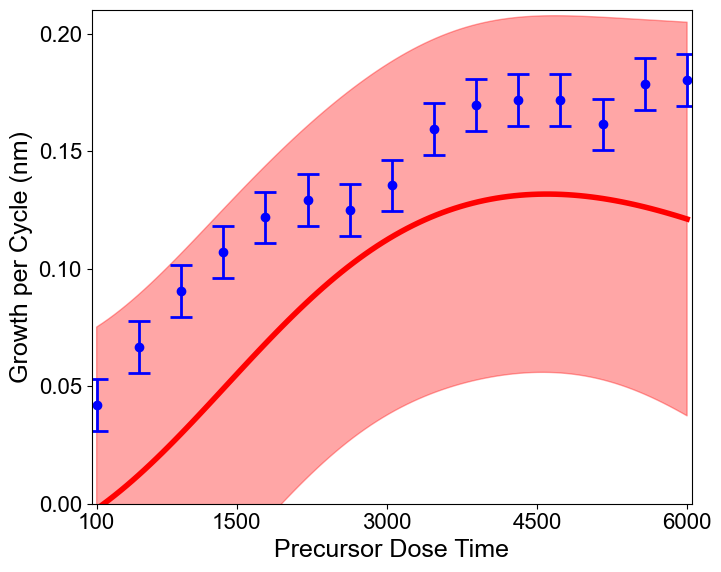

RMSE (plasma_purge_time): 0.055773


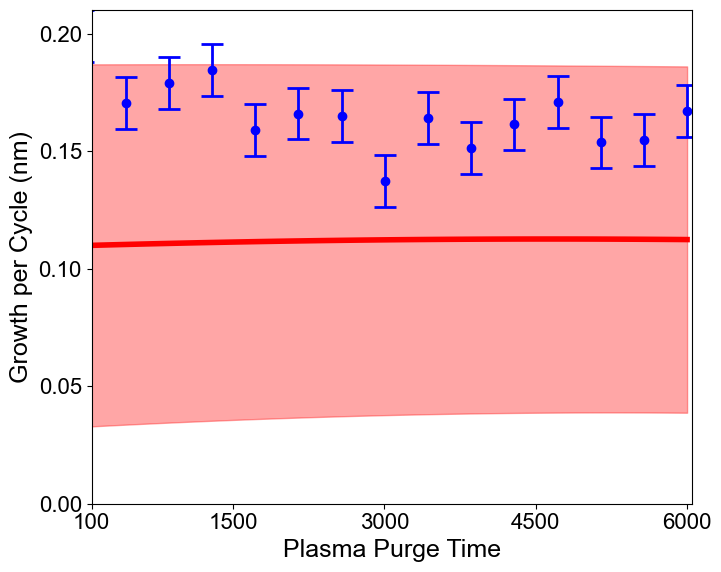

RMSE (process_pressure): 0.013647


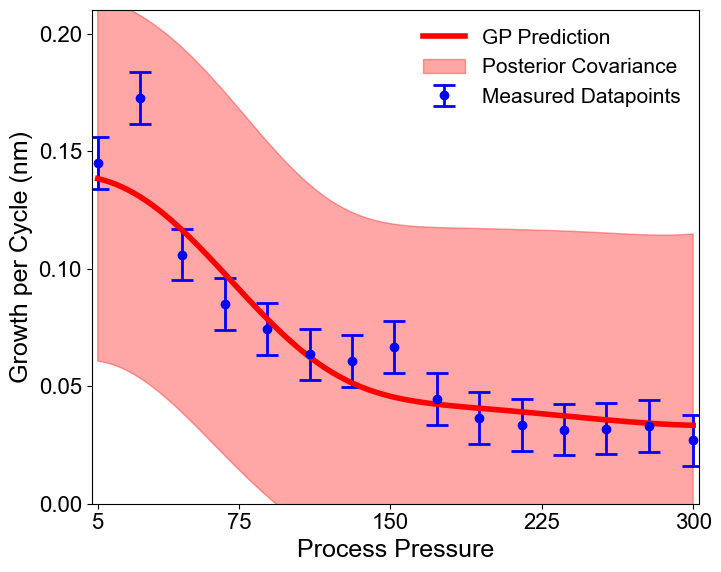

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

SWEEPS_FOLDER = "Sweeps"  # adjust path if needed, e.g. "Data/Sweeps"

# ── Load the three sweeps directly by filename ────────────────────────────────
def load_sweep(filename, sweeps_folder=SWEEPS_FOLDER):
    fpath = os.path.join(sweeps_folder, filename)
    with open(fpath, 'r') as f:
        sweep = json.load(f)
    print(f"✓ Loaded {filename} → sweep_param: {sweep['config']['sweep_param']}")
    return sweep, fpath

sweep_precursor_dose, fpath_precursor_dose = load_sweep("precursor_dose_time_sweep.json")
sweep_plasma_purge, fpath_plasma_purge     = load_sweep("plasma_purge_time_sweep.json")
sweep_process_pressure, fpath_process_pressure = load_sweep("process_pressure_sweep.json")


# ── Plotting function (unchanged) ─────────────────────────────────────────────
def plot_sweep_gp(sweep, sweep_param, gpmodel, config, legend=True,
                 xlabel=None, x_ticks=None, x_lim=None, title=None):

    runs_sweep = pd.DataFrame(sweep['runs'])

    input_points_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
    p0, p1 = sweep['config']['param_limits'][sweep_param]
    sweep_x = np.linspace(p0, p1, 100)
    input_points_dict[sweep_param] = sweep_x
    f, f_std = gpmodel.posterior(pd.DataFrame(input_points_dict, columns=config['modeled_params']))

    actual_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
    actual_dict[sweep_param] = runs_sweep[sweep_param].values
    f_actual, _ = gpmodel.posterior(pd.DataFrame(actual_dict, columns=config['modeled_params']))

    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.sans-serif': ['Arial'],
    })

    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.errorbar(runs_sweep[sweep_param], runs_sweep['dep_rate_mean'],
                yerr=0.011, fmt='o', label='Measured Datapoints', color='blue',
                capsize=8, capthick=2, elinewidth=2)
    ax.plot(sweep_x, f, color='red', label='GP Prediction', linewidth=4)
    ax.fill_between(sweep_x, f - 2*f_std, f + 2*f_std,
                    alpha=0.35, color='red', label='Posterior Covariance')
    ax.set_xlabel(xlabel or sweep_param, fontsize=18)
    ax.set_ylabel('Growth per Cycle (nm)', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
    if x_lim is not None:
        ax.set_xlim(x_lim)
    ax.set_ylim(0.0, 0.21)
    ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20])
    if legend:
        ax.legend(fontsize=15, loc='best', frameon=False)
    if title:
        ax.set_title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

    return fig, ax


# ── Plot Precursor Dose Time ───────────────────────────────────────────────────
fig_precursor, ax_precursor = plot_sweep_gp(
    sweep_precursor_dose, 'precursor_dose_time', gpmodel_final, config,
    xlabel='Precursor Dose Time',
    x_ticks=[100, 1500, 3000, 4500, 6000],
    x_lim=[50, 6050],
    legend=False,
)

# ── Plot Plasma Purge Time ─────────────────────────────────────────────────────
fig_purge, ax_purge = plot_sweep_gp(
    sweep_plasma_purge, 'plasma_purge_time', gpmodel_final, config,
    xlabel='Plasma Purge Time',
    x_ticks=[100, 1500, 3000, 4500, 6000],
    x_lim=[100, 6050],
    legend=False,
)

# ── Plot Process Pressure ──────────────────────────────────────────────────────
fig_pressure, ax_pressure = plot_sweep_gp(
    sweep_process_pressure, 'process_pressure', gpmodel_final, config,
    xlabel='Process Pressure',
    x_ticks=[5, 75, 150, 225, 300],
    x_lim=[2, 303],
    legend=True,
)

# Interactive Slice Slider

In [9]:
max_run = 100 # 300
runs = merged_df.iloc[:max_run]
runs

,run_id,ALD_prep_time,ALD_purge_flow_rate,ALD_purge_plasma_flow_rate,ALD_purge_time,Ar_plasma_flow_rate,Ar_process_flow_rate,H2_plasma_flow_rate,LC_preset,N2_plasma_flow_rate,...,dep_rate_fit,dep_rate_mean,dep_rate_direct,dep_rate_deviation,fit_diff_variation,is_prior,from_recommendation_id,campaign_id,gp_hyperparameters,gpmodel
0,0t49dprknhsak000c3k693h2qg,2000,5,0,4914,0,50,75,50,0,...,0.052116,0.067044,0.139254,0.011,3.383906,True,0t49dprjz9tbb000ssqa8azzhg,0t49dprjynzhz000esnegj1jk8,None,None
1,0t49dy39mny8k000ng6241k8mw,2000,5,0,4201,0,50,75,50,0,...,0.133442,0.143251,0.136092,0.011,6.420534,True,0t49dy3989vjz00075v27g1er8,0t49dprjynzhz000esnegj1jk8,None,None
2,0t49e65mbdz3v000n2g27rnp10,2000,5,0,1488,0,50,75,50,0,...,0.062305,0.066951,0.060408,0.011,3.153647,True,0t49e65ktxwe1000xf7hm7ppnc,0t49dprjynzhz000esnegj1jk8,None,None
3,0t49ed0xmxvaf000zf6x8d54dm,2000,5,0,225,0,50,75,50,0,...,0.111005,0.127140,0.111624,0.011,8.642444,True,0t49ed0wysrb3000hzb025dbq0,0t49dprjynzhz000esnegj1jk8,None,None
4,0t49em4gx1v1q00040qzs718p8,2000,5,0,1885,0,50,75,50,0,...,0.159166,0.200116,0.161080,0.011,14.504230,True,0t49em4epxwef000h404n0meaw,0t49dprjynzhz000esnegj1jk8,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0t4a5v53txvf3000kdnrwmd2f0,2000,5,0,5999,0,50,75,50,0,...,0.147367,0.197271,0.144400,0.011,3.623349,False,0t4a5v53fdvrq000z8z7bn9rkm,0t49fgtahnrvv000294qhkf8jm,"[0.003503387779861554, 1.4998057371905034, 0.4...",<models.gpmodel_constant_PriorMean.GPModelCons...
96,0t4a67ee9dyp90004nqwvh4n0r,2000,5,0,3087,0,50,75,50,0,...,0.090102,0.108438,0.086400,0.011,2.954690,False,0t4a67edz1rr5000hyqwcgqpam,0t49fgtahnrvv000294qhkf8jm,"[0.003466689876784265, 1.4997456723498064, 0.5...",<models.gpmodel_constant_PriorMean.GPModelCons...
97,0t4a6h17a5svn000erv7nbh184,2000,5,0,5999,0,50,75,50,0,...,0.141450,0.176370,0.142400,0.011,3.456001,False,0t4a6h170hwn9000dsnfcj26qr,0t49fgtahnrvv000294qhkf8jm,"[0.0034192671106580697, 1.4999382151382092, 0....",<models.gpmodel_constant_PriorMean.GPModelCons...
98,0t4a6wfdfdyn5000raj6xqnmvw,2000,5,0,10,0,50,75,50,0,...,0.111839,0.160896,0.113600,0.011,2.448045,False,0t4a6wfcynwwf000fzr1ja3qw8,0t49fgtahnrvv000294qhkf8jm,"[0.0033995559998768396, 1.4997650204175126, 0....",<models.gpmodel_constant_PriorMean.GPModelCons...


In [12]:
gpmodel_final = merged_df ['gpmodel'].values[-1]

In [13]:

p = 'precursor_dose_time' #'RF_power_setpoint' # 'precursor_dose_time'
#p = config['modeled_params'][3]

input_points_dict = {}# = pd.DataFrame(columns=config['modeled_params'])

for param in config['modeled_params']:
    input_points_dict[param] = np.mean(config['param_limits'][param])

p0,p1 = config['param_limits'][p]
input_points_dict[p] = np.linspace(p0,p1,100) #make myspace from 4Dplots the same as input_points_dict

prediction_points_df = pd.DataFrame(input_points_dict, columns=config['modeled_params'])
#runs_df = pd.DataFrame(campaign['runs'])

#display(prediction_points_df)
f, v = gpmodel_final.posterior(prediction_points_df)


# Create widgets dictionary
widgets = {}
for param in config['modeled_params']:
    if p == param:
        continue
    widgets[param] = FloatSlider(
        min = config['param_limits'][param][0],
        max = config['param_limits'][param][1],
        value = input_points_dict[param],
        #continuous_update=False,
    )
widgets["max_run"] = IntSlider(
    min = 5,
    max = 300,
    value=300,
    #continous_update=False,
)

def plot_func(**kwargs):
    # Create figure and axis
    plt.figure(figsize=(10, 6))
    
    for param in config['modeled_params']:
        if param == p:
            continue
        prediction_points_df[param] = kwargs[param]

    max_run = kwargs['max_run']

    runs = merged_df.iloc[:max_run]
    
    # remove gpmodel_final and keep the ones after the comment
    gpmodel = gpmodel_final # merged_df.at[max_run, 'gpmodel']

    f, v = gpmodel.posterior(prediction_points_df)

    global current_pred, current_y, current_v
    current_pred = prediction_points_df[p]
    current_y = f
    current_v = v

    #v = 0.1*v
    plt.title(p)
    plt.plot(prediction_points_df[p], f)
    plt.xlabel(p)
    plt.ylabel(config['model_output_param'])
    plt.fill_between(prediction_points_df[p], f - 2. * v, f + 2. * v, alpha = 0.5, color = "red", label = "Posterior Covariance")
    
    # calculate euclidian distance i
    runs_modeled_params_df = runs[config['modeled_params']]
    runs_modeled_params_normalized = gpmodel.scaler.transform(runs_modeled_params_df)
    prediction_points_normalized = gpmodel.scaler.transform(prediction_points_df)
    # prediction_points_normalized_df = pd.DataFrame(prediction_points_normalized,columns=config['modeled_params'])

    def point_to_line_distance(points, line_point1, line_point2):
        """
        Alternative implementation using vector algebra.
        """
        # Line vector
        line_vec = line_point2 - line_point1
        line_length = np.linalg.norm(line_vec)
        
        if line_length == 0:
            raise ValueError("The two points defining the line must be different")
        
        # Unit direction vector
        unit_line_vec = line_vec / line_length
        
        # For each point, calculate the distance
        distances = []
        for point in points:
            # Vector from line_point1 to point
            point_vec = point - line_point1
            
            # Projection of point_vec onto the line
            projection = np.dot(point_vec, unit_line_vec)
            
            # Closest point on the line
            closest_point = line_point1 + projection * unit_line_vec
            
            # Distance from point to closest point
            distance = np.linalg.norm(point - closest_point)
            distances.append(distance)
        
        return np.array(distances)
    
    runs_point_to_line_distance = point_to_line_distance(runs_modeled_params_normalized, prediction_points_normalized[0,:], prediction_points_normalized[1,:])
    colors = runs_point_to_line_distance/np.max(runs_point_to_line_distance)
    #print(runs[p].shape, colors.shape)

    level_scatter_closenes = 0.75
    # plt.scatter(np.array(runs[p])[colors < 0.75], np.array(runs['dep_rate_mean'])[colors < 0.75],  c=colors[colors <0.75], cmap=plt.cm.Greens_r)
    plt.scatter(np.array(runs[p])[colors <level_scatter_closenes], np.array(runs['dep_rate_mean'])[colors < level_scatter_closenes],  c=colors[colors <level_scatter_closenes], cmap=plt.cm.Greens_r)

    ## plt.scatter(np.array(runs[p])[colors < 0.75], np.array(merged_df['dep_rate_mean'])[colors < 0.75],  c=colors[colors <0.75], cmap=plt.cm.Greens_r)
    plt.ylim(0,0.3)
    plt.show()

    
interact(plot_func, **widgets)

interactive(children=(FloatSlider(value=2005.0, description='plasma_prep_time', max=4000.0, min=10.0), FloatSl…

<function __main__.plot_func(**kwargs)>

In [15]:
# def point_to_line_distance2(points, line_point1, line_point2):
#     """
#     Alternative implementation using vector algebra.
#     """
#     # Line vector
#     line_vec = line_point2 - line_point1
#     line_length = np.linalg.norm(line_vec)
    
#     if line_length == 0:
#         raise ValueError("The two points defining the line must be different")
    
#     # Unit direction vector
#     unit_line_vec = line_vec / line_length
    
#     # For each point, calculate the distance
#     distances = []
#     for point in points:
        
#         # Vector from line_point1 to point
#         point_vec = point - line_point1
        
#         # Projection of point_vec onto the line
#         projection = np.dot(point_vec, unit_line_vec)
        
#         # Closest point on the line
#         closest_point = line_point1 + projection * unit_line_vec
        
#         # Distance from point to closest point
#         distance = np.linalg.norm(point - closest_point)
#         distances.append(distance)
    
#     return np.array(distances)

# p = 'precursor_dose_time'
# #p = config['modeled_params'][3]

# input_points_dict = {}# = pd.DataFrame(columns=config['modeled_params'])

# for param in config['modeled_params']:
#     input_points_dict[param] = np.mean(config['param_limits'][param])

# # Just for plotting specific points in run- and parameter-space
# input_points_dict['plasma_prep_time'] = 4000
# input_points_dict['plasma_purge_time'] = 4000
# input_points_dict['ALD_purge_time'] = 6000
# max_run = 10
# yerr = 0.011

# gpmodel = merged_df.at[max_run, 'gpmodel']

# p0,p1 = config['param_limits'][p]
# input_points_dict[p] = np.linspace(p0,p1,10) #make myspace from 4Dplots the same as input_points_dict

# prediction_points_df = pd.DataFrame(input_points_dict, columns=config['modeled_params'])
# # calculate euclidian distance i
# runs_modeled_params_df = runs[config['modeled_params']]
# runs_modeled_params_normalized = gpmodel.scaler.transform(runs_modeled_params_df)
# prediction_points_normalized = gpmodel.scaler.transform(prediction_points_df)

# #display(prediction_points_df)
# f, v = gpmodel.posterior(prediction_points_df)

# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.serif': ['Arial'],
#     'font.size': 12
# })

# # Create figure and axis

# plt.figure(figsize=(9, 6))

# runs = merged_df.iloc[:max_run]

# gpmodel = merged_df.at[max_run, 'gpmodel']

# f, v = gpmodel.posterior(prediction_points_df)

# global current_pred, current_y, current_v
# current_pred = prediction_points_df[p]
# current_y = f
# current_v = v

# plt.plot(prediction_points_df[p], f, color = "darkblue", label = "GP Prediction")
# plt.xlabel("Precursor Dose Time (ms)", fontsize = 16)
# plt.ylabel("Growth per Cycle (nm)", fontsize = 16)
# plt.fill_between(prediction_points_df[p], f - 2. * v, f + 2. * v, alpha = 0.5, color = "red", label = "Posterior Covariance")


# # Normalize distances to [0, 1] for colormapping
# runs_point_to_line_distance = point_to_line_distance2(runs_modeled_params_normalized, prediction_points_normalized[0,:], prediction_points_normalized[1,:])
# distances = runs_point_to_line_distance
# colors = distances / np.max(distances)

# # Mask for points below the threshold
# mask = colors < 1

# x_vals = np.array(runs[p])[mask]
# y_vals = np.array(runs['dep_rate_mean'])[mask]

# # Make sure yerr is the right shape
# yerr_vals = np.full_like(y_vals, yerr)  # fills array with the same yerr value

# # Colormap setup
# cmap = plt.cm.Blues_r
# norm = mpl.colors.Normalize(vmin=0, vmax=1)  # ensures consistent scaling

# # Scatter plot
# sc = plt.scatter(x_vals, y_vals, c=colors[mask], cmap=cmap, norm=norm,
#                  label="Measured Datapoints")

# # Error bars with matching colors
# for xi, yi, ye, ci in zip(x_vals, y_vals, yerr_vals, colors[mask]):
#     plt.errorbar(xi, yi, yerr=ye, linestyle="None", capsize=5,
#                  color=cmap(norm(ci)))

# # Plot settings
# plt.ylim(0, 0.25)
# plt.xlim(0, 6000)
# plt.tick_params(axis="y", direction="in")
# plt.tick_params(axis="x", direction="in")
# plt.tick_params(top=True, right=True)
# #plt.legend(loc='upper left')
# cb = plt.colorbar(sc)  # optional colorbar
# cb.set_label(label="Norm. Distance from Slice", fontsize = 14)
# plt.show()

In [16]:

# Set plot parameters
p = 'precursor_dose_time'
yerr = 0.011

# Set up input points for prediction
input_points_dict = {}
for param in config['modeled_params']:
    input_points_dict[param] = np.mean(config['param_limits'][param])

# Override specific values
input_points_dict['plasma_prep_time'] = 4000
input_points_dict['plasma_purge_time'] = 4000
input_points_dict['ALD_purge_time'] = 6000

# Create prediction points
p0, p1 = config['param_limits'][p]
input_points_dict[p] = np.linspace(p0, p1, 100)
prediction_points_df = pd.DataFrame(input_points_dict, columns=config['modeled_params'])
prediction_points_df

,plasma_prep_time,precursor_dose_time,plasma_purge_time,ALD_purge_time
0,4000,100.000000,4000,6000
1,4000,159.595960,4000,6000
2,4000,219.191919,4000,6000
3,4000,278.787879,4000,6000
4,4000,338.383838,4000,6000
...,...,...,...,...
95,4000,5761.616162,4000,6000
96,4000,5821.212121,4000,6000
97,4000,5880.808081,4000,6000
98,4000,5940.404040,4000,6000


In [ ]:
# SAME AS ABOVE, BUT LOOPING THROUGH DIFFERENT max_run VALUES AND SAVING PLOTS

# def point_to_line_distance2(points, line_point1, line_point2):
#     """
#     Alternative implementation using vector algebra.
#     """
#     # Line vector
#     line_vec = line_point2 - line_point1
#     line_length = np.linalg.norm(line_vec)
    
#     if line_length == 0:
#         raise ValueError("The two points defining the line must be different")
    
#     # Unit direction vector
#     unit_line_vec = line_vec / line_length
    
#     # For each point, calculate the distance
#     distances = []
#     for point in points:
        
#         # Vector from line_point1 to point
#         point_vec = point - line_point1
        
#         # Projection of point_vec onto the line
#         projection = np.dot(point_vec, unit_line_vec)
        
#         # Closest point on the line
#         closest_point = line_point1 + projection * unit_line_vec
        
#         # Distance from point to closest point
#         distance = np.linalg.norm(point - closest_point)
#         distances.append(distance)
    
#     return np.array(distances)



# Set plot parameters
p = 'precursor_dose_time'
yerr = 0.011

# Set up input points for prediction
input_points_dict = {}
for param in config['modeled_params']:
    input_points_dict[param] = np.mean(config['param_limits'][param])

# Override specific values
input_points_dict['plasma_prep_time'] = 4000
input_points_dict['plasma_purge_time'] = 4000
input_points_dict['ALD_purge_time'] = 6000

# Create prediction points
p0, p1 = config['param_limits'][p]
input_points_dict[p] = np.linspace(p0, p1, 100)
prediction_points_df = pd.DataFrame(input_points_dict, columns=config['modeled_params'])

# Set matplotlib parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Arial'],
    'font.size': 12
})

# Loop through different max_run values
max_run_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 99]

# max_run_values = [99]

for max_run in max_run_values:
    print(f"Generating plot for max_run = {max_run}")
    
    # Create figure
    fig = plt.figure(figsize=(7.3, 6))
    
    # Get data
    runs = merged_df.iloc[:max_run]
    gpmodel = merged_df.at[max_run, 'gpmodel']
    
    # Get posterior predictions
    f, v = gpmodel.posterior(prediction_points_df)
    

    if max_run==99:
        
        # Option 1: plasma at a higher position (more orange)
        shade_color = plt.cm.plasma(0.75)  # ~#f1844b, warm orange

        # Shade the ALD window region
        plt.axvspan(3000, 6000, alpha=0.2, color=shade_color, label=' ', zorder=0)  # ALD Window
        plt.axvline(3000, color=shade_color, linestyle='--',  alpha=0.5, linewidth=2)
    

    # Plot GP prediction
    plt.plot(prediction_points_df[p], f, color="red", label=" ", linewidth = 3 ) # GP Prediction")  "darkblue"
    plt.xlabel("Precursor Dose Time (ms)", fontsize=16)
    plt.ylabel("Growth per Cycle (nm)", fontsize=16)
    plt.fill_between(prediction_points_df[p], f - 2. * v, f + 2. * v, 
                     alpha=0.35, color="red", label=" " ) # Posterior Covariance")
    
    # # Calculate distances
    # runs_modeled_params_df = runs[config['modeled_params']]
    # runs_modeled_params_normalized = gpmodel.scaler.transform(runs_modeled_params_df)
    # prediction_points_normalized = gpmodel.scaler.transform(prediction_points_df)
    
    # runs_point_to_line_distance = point_to_line_distance2(
    #     runs_modeled_params_normalized, 
    #     prediction_points_normalized[0,:], 
    #     prediction_points_normalized[-1,:]
    # )
    
    # # Normalize distances
    # distances = runs_point_to_line_distance
    # colors = distances / np.max(distances)
    
    # # Mask for points below threshold
    # mask = colors < 1
    
    # x_vals = np.array(runs[p])[mask]
    # y_vals = np.array(runs['dep_rate_mean'])[mask]
    # yerr_vals = np.full_like(y_vals, yerr)
    
    # # Colormap setup
    # cmap = plt.cm.Blues_r
    # norm = mpl.colors.Normalize(vmin=0, vmax=1)
    
    # # Scatter plot
    # sc = plt.scatter(x_vals, y_vals, c=colors[mask], cmap=cmap, norm=norm,
    #                  label=" " ) # Measured Datapoints")
    
    # # Error bars with matching colors
    # for xi, yi, ye, ci in zip(x_vals, y_vals, yerr_vals, colors[mask]):
    #     plt.errorbar(xi, yi, yerr=ye, linestyle="None",
    #                 capsize=8,         # length of the caps (was 5)
    #                 capthick=2,        # thickness of the caps
    #                 elinewidth=2,      # thickness of the vertical error bar line
    #                 color=cmap(norm(ci)))
    
    # Plot settings
    plt.ylim(0, 0.25)
    plt.xlim(0, 6000)
    plt.tick_params(axis="y") #, direction="in")
    plt.tick_params(axis="x")#, direction="in")
    # plt.tick_params(top=True, right=True)
    
    # if max_run==10:
    #     plt.legend(loc='lower right',frameon = False, fontsize =15)

    # # Colorbar
    # cb = plt.colorbar(sc)
    # cb.set_label(label="Norm. Distance from Slice", fontsize=14)
    



    # Add title with iteration number
    plt.title(f"Iteration {max_run}", fontsize=14)
    
    plt.tight_layout()
    
    # Save plots
    png_file = os.path.join(campaign_dir, f"slice_iteration_{max_run:03d}.png")
    pdf_file = os.path.join(campaign_dir, f"slice_iteration_{max_run:03d}.pdf")
    
    plt.savefig(png_file, dpi=300, bbox_inches='tight')
    plt.savefig(pdf_file, bbox_inches='tight')
    
    plt.close()
    
    print("Saved")

print(f"\nAll plots saved to: {campaign_dir}")

Generating plot for max_run = 10
Saved
Generating plot for max_run = 20
Saved
Generating plot for max_run = 30
Saved
Generating plot for max_run = 40
Saved
Generating plot for max_run = 50
Saved
Generating plot for max_run = 60
Saved
Generating plot for max_run = 70
Saved
Generating plot for max_run = 80
Saved
Generating plot for max_run = 90
Saved
Generating plot for max_run = 99
Saved

All plots saved to: /Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/Slices/Campaign_0009


In [ ]:
# Define the parameter values to save
param_values = {}
for param in config['modeled_params']:
    if param == p:
        continue
    min_val, max_val = config['param_limits'][param]
    param_values[param] = [min_val, (min_val + max_val) / 2, max_val]

# Generate all combinations of parameter values
param_combinations = list(itertools.product(*param_values.values()))

# Save plots for each combination
for i, combination in enumerate(param_combinations):
    kwargs = dict(zip(param_values.keys(), combination))
    kwargs['max_run'] = 99
    
    # Create figure and axis
    plt.figure(figsize=(10, 6))
    
    for j, param in enumerate(config['modeled_params']):
        if param == p:
            continue
        prediction_points_df[param] = kwargs[param]

    max_run = kwargs['max_run']

    runs = runs_df.iloc[:max_run]
    
    gpmodel = merged_df.at[max_run, 'gpmodel']

    f, v = gpmodel.posterior(prediction_points_df)

    global current_pred, current_y, current_v
    current_pred = prediction_points_df[p]
    current_y = f
    current_v = v

    #v = 0.1*v
    plt.title(p)
    plt.plot(prediction_points_df[p], f)
    plt.xlabel(p)
    plt.ylabel(config['model_output_param'])
    plt.fill_between(prediction_points_df[p], f - 2. * v, f + 2. * v, alpha = 0.5, color = "red")
    
    # calculate euclidian distance i
    runs_modeled_params_df = runs[config['modeled_params']]
    runs_modeled_params_normalized = gpmodel.scaler.transform(runs_modeled_params_df)
    prediction_points_normalized = gpmodel.scaler.transform(prediction_points_df)
    # prediction_points_normalized_df = pd.DataFrame(prediction_points_normalized,columns=config['modeled_params'])

    def point_to_line_distance(points, line_point1, line_point2):
        """
        Alternative implementation using vector algebra.
        """
        # Line vector
        line_vec = line_point2 - line_point1
        line_length = np.linalg.norm(line_vec)
        
        if line_length == 0:
            raise ValueError("The two points defining the line must be different")
        
        # Unit direction vector
        unit_line_vec = line_vec / line_length
        
        # For each point, calculate the distance
        distances = []
        for point in points:
            # Vector from line_point1 to point
            point_vec = point - line_point1
            
            # Projection of point_vec onto the line
            projection = np.dot(point_vec, unit_line_vec)
            
            # Closest point on the line
            closest_point = line_point1 + projection * unit_line_vec
            
            # Distance from point to closest point
            distance = np.linalg.norm(point - closest_point)
            distances.append(distance)
        
        return np.array(distances)
    
    runs_point_to_line_distance = point_to_line_distance(runs_modeled_params_normalized, prediction_points_normalized[0,:], prediction_points_normalized[1,:])
    colors = runs_point_to_line_distance/np.max(runs_point_to_line_distance)
    #print(runs[p].shape, colors.shape)

    plt.scatter(np.array(runs[p])[colors < 0.75], np.array(runs['dep_rate_fit'])[colors < 0.75],  c=colors[colors <0.75], cmap=plt.cm.Greens_r)
    plt.ylim(0.01,0.25)
    
    # Add legend
    legend_text = f"{config['modeled_params'][0]}={combination[0]:.2f}\n{config['modeled_params'][2]}={combination[1]:.2f}\n{config['modeled_params'][3]}={combination[2]:.2f}"
    plt.figtext(0.89, 0.8, legend_text, ha="right", fontsize=10)
    
    # save image
    slider_filename = f"Plots/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_slider_{combination}.png"
    plt.savefig(slider_filename, bbox_inches='tight')
    plt.close()

NameError: name 'runs_df' is not defined

<Figure size 1000x600 with 0 Axes>

# 4D Plots

In [48]:
def plot(X, Y, Z, W, mean_colorbar_limits=None, data=None, var_name=None,
         lower_bounds=None, upper_bounds=None, filename=None,
         colorbar_title=None, plt_idx=None,
         line_x=None, line_z=None, line_color='black', line_width=8):

    axis_title_size = 22
    axis_ticks_size = 15

    var_names_3D = [element for i, element in enumerate(var_name) if i != plt_idx]
    lower_bounds_3D = [element for i, element in enumerate(lower_bounds) if i != plt_idx]
    upper_bounds_3D = [element for i, element in enumerate(upper_bounds) if i != plt_idx]
    y_data = data[:, 4]
    data_3D = np.delete(data[:, 0:4], plt_idx, axis=1)

    fig = go.Figure()

    if data is not None:
        fig.add_trace(go.Scatter3d(
            x=data_3D[:, 0],
            y=data_3D[:, 1],
            z=data_3D[:, 2],
            mode='markers',
            marker=dict(
                size=15,
                color=y_data,
                opacity=0.8,
                colorscale="Plasma",
                cmin=mean_colorbar_limits[0],
                cmax=mean_colorbar_limits[1]),
            showlegend=False))

        fig.add_trace(go.Scatter3d(
            x=data_3D[:, 0],
            y=data_3D[:, 1],
            z=data_3D[:, 2],
            mode='markers',
            marker=dict(
                size=17,
                color='black',
                symbol='circle-open',
                line=dict(width=3)
            ),
            showlegend=False
        ))

    # --- NEW: add a straight line at fixed x, z, spanning full y-range ---
    if line_x is not None and line_z is not None:
        fig.add_trace(go.Scatter3d(
            x=[line_x, line_x],
            y=[lower_bounds_3D[1], upper_bounds_3D[1]],
            z=[line_z, line_z],
            # mode='lines',
            line=dict(color=line_color, width=line_width),
            showlegend=False
        ))
    # ----------------------------------------------------------------------

    for i in range(0, len(Z[0, 0, :]), 3):
        fig.add_trace(go.Surface(
            x=X[:, :, i],
            y=Y[:, :, i],
            z=Z[:, :, i],
            surfacecolor=W[:, :, i],
            colorscale='Plasma',
            cmin=mean_colorbar_limits[0],
            cmax=mean_colorbar_limits[1],
            opacity=0.85,
            colorbar=dict(
                title=colorbar_title,
                ticks='outside',
                tickfont=dict(size=axis_ticks_size * 1.5, color='black'),
                len=0.8)))

    fig.update_layout(
        width=1000,
        height=1000,
        margin=dict(l=65, r=50, b=65, t=90),
        scene=dict(
            xaxis_title=" ",
            yaxis_title=" ",
            zaxis_title=" ",
            xaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals=[""],
                range=[lower_bounds_3D[0], upper_bounds_3D[0]]
            ),
            yaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals=[""],
                range=[lower_bounds_3D[1], upper_bounds_3D[1]]
            ),
            zaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals=[""],
                range=[lower_bounds_3D[2] * 0.99, upper_bounds_3D[2] * 1.01]
            ),
            aspectmode='cube',
            camera=dict(
                eye=dict(x=-1.5, y=1.5, z=1.5)
            )))

    if filename is not None:
        if filename.endswith('.html'):
            fig.write_html(
                filename,
                config={
                    'toImageButtonOptions': {
                        'format': 'svg',
                        'filename': filename.replace('.html', ''),
                        'height': 1000,
                        'width': 1000,
                        'scale': 2
                    }
                }
            )
        else:
            fig.write_image(filename, width=1000, height=1000)

    fig.show()

# Plotting the results on a 3D plot
def plot_Uncertainty(X, Y, Z, W, var_colorbar_limits,var_name = None, lower_bounds = None, upper_bounds = None , filename=None, plt_idx = None):
    fig = go.Figure()

    axis_title_size = 30
    axis_ticks_size = 15

    var_names_3D = [element for i, element in enumerate(var_name) if i != plt_idx]
    lower_bounds_3D = [element for i, element in enumerate(lower_bounds) if i != plt_idx]
    upper_bounds_3D = [element for i, element in enumerate(upper_bounds) if i != plt_idx]


    for i in range(0, len(Z[0, 0, :]),3):
        fig.add_trace(go.Surface(
            x=X[:, :, i],
            y=Y[:, :, i],
            z=Z[:, :, i],
            surfacecolor=W[:, :, i],
            cmin=var_colorbar_limits[0],
            cmax=var_colorbar_limits[1],
            colorscale='Viridis',  # Set the Viridis colormap
            colorbar= dict(
                title=' ',
                tickvals=[0.007,0.009,0.011,0.013,0.015],
                ticks='outside',
                tickfont=dict(size=axis_ticks_size*1.5),
                len=0.8,  # Adjust the length of the color bar (0.5 represents half the length)
            )
        ))

    fig.update_layout(
        #title='Plot',
        #autosize=True,
        width=1000,
        height=1000,
        margin=dict(l=65, r=50, b=65, t=90),
        scene=dict(
            xaxis_title= ' ' , # var_names_3D[0],
            yaxis_title= ' ' , # var_names_3D[1],
            zaxis_title= ' ' , # var_names_3D[2],
            xaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals=[""], # np.linspace(lower_bounds_3D[0], upper_bounds_3D[0],3), #[15, 30, 45], #np.linspace(20, 80, 4),  # Set the x-axis tick values (4 evenly spaced values)
                #ticktext=[""], #np.array([20,40,60,80]),  # Set the x-axis tick labels (same as tick values)
                range=[lower_bounds_3D[0], upper_bounds_3D[0]]  # Set the x-axis range
                ),
            yaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals=[""], # np.linspace(lower_bounds_3D[1], upper_bounds_3D[1],3), #[100, 125, 150, 175, 200], #np.linspace(2, 8, 4),  # Set the y-axis tick values (4 evenly spaced values)
                #ticktext=[""],#np.array([2,4,6,8]),  # Set the y-axis tick labels (same as tick values)
                range=[lower_bounds_3D[1], upper_bounds_3D[1]]  # Set the x-axis range
                ),
            zaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                tickvals =[""], # np.linspace(lower_bounds_3D[2], upper_bounds_3D[2],3), # , #[20,40,60] ,#np.linspace(10, 40, 4),  # Set the y-axis tick values (4 evenly spaced values)
                #ticktext = [""],#np.array([10,20,30,40]),  # Set the y-axis tick labels (same as tick values)
                range=[lower_bounds_3D[2]*0.99, upper_bounds_3D[2]*1.01]
                ),

        aspectmode='cube',    
        camera=dict(
            eye=dict(x=-1.5, y=1.5, z=1.5)  # Adjust these values to control zoom
        )
        )
    )

    if filename is not None:
        if filename.endswith('.html'):
            fig.write_html(
                filename,
                config={
                    'toImageButtonOptions': {
                        'format': 'svg',
                        'filename': filename.replace('.html', ''),
                        'height': 1000,
                        'width': 1000,
                        'scale': 2
                    }
                }
            )
        else:
            fig.write_image(filename, width=1000,height=1000)

    fig.show()

In [49]:
#Define parameter space:

var_names = config['modeled_params']
fixed_var_name = 'ALD_purge_time'
fixed_var_idx = var_names.index(fixed_var_name)

fixed_var_level = 6000. # Fixed value for lead parameter = [10, 2000,4000,6000]

tolerance = 1000

num_points = 10

lower_bounds = []
upper_bounds = []
for param in var_names:
     lower_bounds.append(config['param_limits'][param][0])
     upper_bounds.append(config['param_limits'][param][1])

# Indices for each variable
vary_indices = [i for i in range(4) if i != fixed_var_idx]

#################################################
# Parameter Space Grid
# Prepare grid axes for the three variables to vary
grid_axes = [np.linspace(lower_bounds[i], upper_bounds[i], num_points) for i in vary_indices]

X1, X2, X3 = np.meshgrid(*grid_axes, indexing='ij')

# Flatten the mesh to get all combinations
points = np.vstack([X1.ravel(), X2.ravel(), X3.ravel()]).T

# Insert the fixed variable at fixed_var_idx
my_space = np.empty((points.shape[0], 4))
for i, idx in enumerate(vary_indices):
    my_space[:, idx] = points[:, i]
my_space[:, fixed_var_idx] = fixed_var_level  # fixed value for lead parameter
my_space_df = pd.DataFrame(my_space, columns=var_names)
#################################################

gpmodel_final = merged_df ['gpmodel'].values[-1]

# Doing the predictions
f, v = gpmodel_final.posterior(my_space_df)
f_re = f.reshape(num_points, num_points, num_points)      # This is the prediction


###################################################################################
# comment out if no actual data used
# get measured datapoints
x_data_norm = gpmodel_final.my_gpo.x_data
x_data = gpmodel_final.scaler.inverse_transform(x_data_norm)
y_data = gpmodel_final.my_gpo.y_data
# select data within tolerance of selected plane
mask = np.abs(x_data[:, fixed_var_idx].astype(float) - fixed_var_level) < tolerance
data = np.column_stack([
    x_data[mask, :].astype(float),
    y_data[mask]
])

print("Number of data points within tolerance:", data.shape[0])

#####################################################################################

print(np.min(f), np.max(f))

filename = f"Plots/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_4DTest_{fixed_var_name}_{fixed_var_level}.pdf" #used to save the plot

filename = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/4D plots/Campaign_{campaign_num}/{fixed_var_name}_{fixed_var_level}.pdf" #used to save the plot
#filename = f"G:/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/4D plots/Campaign_{campaign_num}/{fixed_var_name}_{fixed_var_level}.pdf" #used to save the plot



mean_colorbar_limits = np.array([0, y_data.max()])
    
# plot(X1, 
#      X2, 
#      X3, 
#      f_re, 
#      mean_colorbar_limits = mean_colorbar_limits, 
#      data = data, 
#      lower_bounds=lower_bounds, 
#      upper_bounds=upper_bounds, 
#      var_name=var_names,
#      filename=filename, 
#      colorbar_title="GR (nm)",
#      plt_idx = fixed_var_idx) 

plot(X1, X2, X3, f_re,
     mean_colorbar_limits=mean_colorbar_limits,
     data=data,
     lower_bounds=lower_bounds,
     upper_bounds=upper_bounds,
     var_name=var_names,
     filename=filename,
     colorbar_title="GR (nm)",
     plt_idx=fixed_var_idx,
     line_x=3920,
     line_z=4070,
     line_width = 50,
     line_color = "red")

Number of data points within tolerance: 35
0.0015001539529558572 0.24501150204231392


In [ ]:
# uncertainty plot

v_re = v.reshape(num_points, num_points,num_points) #check if needed or not

#var_colorbar_limits = np.array([0.4, 1.5]) # Modify

#var_colorbar_limits = np.array([np.min(v), np.max(v)]) # Modify

print(np.array([np.min(v), np.max(v)]))

var_colorbar_limits = np.array([0.007, 0.015])

# #################################################################
filename = f"Plots/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_4DTest_{fixed_var_level}_Uncertainty.pdf" #used to save the plot
filename = f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/4D plots/Campaign_{campaign_num}/{fixed_var_name}_{fixed_var_level}_Uncertainty.pdf" #used to save the plot

#filename = None

plot_Uncertainty(X = X1, 
                 Y = X2,
                 Z = X3, 
                 W = v_re,
                 var_name=var_names,
                 lower_bounds = lower_bounds,
                 upper_bounds = upper_bounds,
                 var_colorbar_limits = var_colorbar_limits, 
                 filename = filename,
                 plt_idx = fixed_var_idx
                 )


[0.00798995 0.0148581 ]


# Combining all the data from campaign 18, 19 and the sweeps

In [ ]:
# # Adding the experimental data from the Campaign 0018

# # Read all the data for the current campaign
# campaign_num_2 = "0018"
# # Find the campaign date
# for dirname in os.listdir("campaigns"):
#     if f"_TDMAT_campaign{campaign_num_2}" in dirname:
#         campaign_date_2 = dirname.split('_')[0]
        
# in_file2 = f"campaigns/{campaign_date_2}_TDMAT_campaign{campaign_num_2}/{campaign_date_2}_TDMAT_campaign{campaign_num_2}_campaign_overview.yaml"

# with open(in_file2, 'r') as f:
#     campaign2 = yaml.safe_load(f)

# # Extract num_runs and gp_model in the same order in configs (first it is random, then BO) 
# gp_model_list = [config['gp_model'] for config in campaign2['configs']]

# merged_df_2 = pd.DataFrame(campaign2['runs'])

# # Specifying the GP model name
# if gp_model_list[-1]!='x:x':
#     gp_model_path = gp_model_list[-1]
# else:
#     gp_model_path = 'models.gpmodel_constant_PriorMean:GPModelConstMean'


# # Optional: replacing the fs growth rate data with refellips postprocessed data
# refellips_file2 = pd.read_csv(f"campaigns/{campaign_date_2}_TDMAT_campaign{campaign_num_2}/{campaign_date_2}_TDMAT_campaign{campaign_num_2}_growth_and_rmse_summary_fixedCauchy.csv")
# # Convert to numeric (handles whitespace and string-formatted numbers)
# merged_df_2['dep_rate_mean'] = pd.to_numeric(refellips_file2['Lin_GPC_nm'], errors='coerce')

# merged_df_2['dep_rate_deviation'] = 0.011

# merged_df_combined = pd.concat([merged_df, merged_df_2], ignore_index=True)
# merged_df_combined



# # # Get the index of the last row
# # last_idx = merged_df_combined.index[-1]

# # # Fit the GP Model with all data 
# # merged_df_combined.at[last_idx, 'gpmodel'] = GPmodel(merged_df_combined, 
# #                                                 input_names=config['modeled_params'], 
# #                                                 output_name='dep_rate_mean',
# #                                                 parameter_space_limits=parameter_space_limits,
# #                                                 output_deviation_variable='dep_rate_deviation',
# #                                                 train_method="global",
# #                                                 train_max_iter=4000)


,run_id,ALD_prep_time,ALD_purge_flow_rate,ALD_purge_plasma_flow_rate,ALD_purge_time,Ar_plasma_flow_rate,Ar_process_flow_rate,H2_plasma_flow_rate,LC_preset,N2_plasma_flow_rate,...,is_prior,from_recommendation_id,campaign_id,gp_hyperparameters,gpmodel,rmse_all_exp,rmse_all_exp_sem,rmse_current_exp,rmse_current_exp_sem,information_gain
0,0t5t37dkehr2v000xp6zpmahmr,964,10,0,4695,0,40,34,50,0,...,True,0t5t37dj0htnf000rfhyr549fr,0t5t37dhzxrwf0003v982kgb8r,None,None,NaN,NaN,NaN,NaN,NaN
1,0t5t3g899xzj7000ehgpjshxr4,1385,14,0,2261,0,89,36,50,0,...,True,0t5t3g88mxvmx000n6pkteg0wc,0t5t37dhzxrwf0003v982kgb8r,None,None,NaN,NaN,NaN,NaN,NaN
2,0t5t3t9d3nwt1000kszw28th3g,825,11,0,908,0,46,84,50,0,...,True,0t5t3t9c19x1n00085fjcpsq2c,0t5t37dhzxrwf0003v982kgb8r,None,None,NaN,NaN,NaN,NaN,NaN
3,0t5t413gf1zcx000zwvecgvtdm,2599,3,0,116,0,56,76,50,0,...,True,0t5t413frhtnd000y397vt7kpr,0t5t37dhzxrwf0003v982kgb8r,None,None,NaN,NaN,NaN,NaN,NaN
4,0t5t48a67nvm7000x9by6hd684,1731,6,0,2008,0,83,92,50,0,...,True,0t5t48a5g5yxq0000jxs9ne4ar,0t5t37dhzxrwf0003v982kgb8r,None,None,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0t5txr21anvns00030afn8z6mg,305,17,0,4533,0,95,40,50,0,...,True,0t5txr20nsy41000brr4cwzvwm,0t5t37dhzxrwf0003v982kgb8r,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,0t5ty1c8p5rfq0003zhg72mggg,1072,19,0,3904,0,50,95,50,0,...,True,0t5ty1c81hykq000vbjwb4sc7m,0t5t37dhzxrwf0003v982kgb8r,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,0t5tybmatdych000wk9n7zzxsc,1626,18,0,816,0,99,65,50,0,...,True,0t5tybma2hzkn000zw773tftnr,0t5t37dhzxrwf0003v982kgb8r,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,0t5tynwmz5xxn000hjgjjsr7sr,3496,16,0,2805,0,83,58,50,0,...,True,0t5tynwm65wwn000rzax3b100w,0t5t37dhzxrwf0003v982kgb8r,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# # Combining the sweeps data
# # merged_df_combined already exists from earlier

# # Dynamic path construction
# if campaign_num =='0019':
#     sweeps_folder = f"Data/{campaign_date}_TDMAT_Campaign{campaign_num}/ThirdSweeps"
# else:
#     sweeps_folder = f"Data/{campaign_date}_TDMAT_Campaign{campaign_num}/Sweeps"

# refellips = True #replacing filmsense data with refellips postprocessed growth rates

# # Check if Sweeps folder exists
# if os.path.exists(sweeps_folder):
#     # Find all JSON files in the Sweeps folder without glob
#     all_files = os.listdir(sweeps_folder)
#     json_files = [f for f in all_files if f.endswith('.json')]
#     fpaths = [os.path.join(sweeps_folder, f) for f in json_files]


# # Only proceed if we found JSON files
# if fpaths:
    
#     all_sweep_dfs = []  # Collect all sweep dataframes
    
#     for i, fpath in enumerate(fpaths):

#         # Load sweep data
#         with open(fpath, 'r') as f:
#             sweep = json.load(f)
        
#         if campaign_num == "0019":
#             idx_ranges_sweeps = np.array([
#                 [39, 52],
#                 [26, 39],
#                 [0, 13],
#                 [13, 26],
#                 [52, 65]
#             ])
            
#             sweep['config']['sweep_param'] = [
#                 "ALD_purge_flow_rate",
#                 "precursor_dose_time",
#                 "plasma_purge_time",
#                 "Ar_process_flow_rate",
#                 "plasma_prep_time"
#             ]
            
#             sweep_param_name_idx = i
#         else:
#             sweep_param_name_idx = 0

#         sweep_param = sweep['config']['sweep_param'][sweep_param_name_idx]
#         runs_sweep = pd.DataFrame(sweep['runs'])

#         # Replace with refellips data if needed
#         if refellips and campaign_num == "0019":
#             refellips_sweep_file = pd.read_csv(
#                 f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_Sweeps_growth_and_rmse_summary_fixedCauchy.csv"
#             )
#             runs_sweep = runs_sweep.tail(13)
#             runs_sweep['dep_rate_mean'] = pd.to_numeric(
#                 refellips_sweep_file['Lin_GPC_nm'].values[idx_ranges_sweeps[i, 0]:idx_ranges_sweeps[i, 1]],
#                 errors='coerce'
#             )
#         elif refellips:
#             refellips_sweep_file = pd.read_csv(
#                 f"campaigns/{campaign_date}_TDMAT_campaign{campaign_num}/{campaign_date}_TDMAT_campaign{campaign_num}_Sweep{i+1}_growth_and_rmse_summary_fixedCauchy.csv"
#             )
#             runs_sweep['dep_rate_mean'] = pd.to_numeric(
#                 refellips_sweep_file['Lin_GPC_nm'].values,
#                 errors='coerce'
#             )
        
#         # Create sweep dataframe with the number of rows from runs_sweep
#         num_rows = len(runs_sweep)
#         sweep_df = pd.DataFrame(index=range(num_rows))
        
#         # Fill in ALL constant parameters from sweep config for ALL rows
#         for param in config['modeled_params']:
#             if param == sweep_param:
#                 # This is the varying parameter - use values from runs_sweep
#                 sweep_df[param] = runs_sweep[sweep_param].values
#             else:
#                 # This is a constant parameter - use the same value for all rows
#                 sweep_df[param] = sweep['config']['params'][param]
        
#         # Add growth rate data
#         sweep_df['dep_rate_mean'] = runs_sweep['dep_rate_mean'].values
#         sweep_df['dep_rate_deviation'] = 0.011
        
#         # Mark as prior data
#         sweep_df['is_prior'] = True
        
#         all_sweep_dfs.append(sweep_df)
        
#         print(f"Sweep {i}: Added {len(sweep_df)} datapoints for {sweep_param}")
    
#     # Concatenate all sweep data
#     if all_sweep_dfs:
#         all_sweeps_combined = pd.concat(all_sweep_dfs, ignore_index=True)
        
#         # Concatenate with merged_df_combined
#         merged_df_combined_2 = pd.concat(
#             [merged_df_combined, all_sweeps_combined], 
#             ignore_index=True
#         )
        
#         print(f"\nTotal datapoints after adding sweeps: {len(merged_df_combined_2)}")
#         print(f"Sweep datapoints added: {len(all_sweeps_combined)}")

# print(len(merged_df_combined_2))

# # Now train GP model with all data
# last_idx = merged_df_combined_2.index[-1]
# merged_df_combined_2.at[last_idx, 'gpmodel'] = GPmodel(merged_df_combined_2, 
#                                                         input_names=config['modeled_params'], 
#                                                         output_name='dep_rate_mean',
#                                                         parameter_space_limits=parameter_space_limits,
#                                                         output_deviation_variable='dep_rate_deviation',
#                                                         train_method="global",
#                                                         train_max_iter=4000
# )

# gpmodel_final = merged_df_combined_2.at[last_idx, 'gpmodel']
# print("GP model trained with all data (campaigns + sweeps)")

Sweep 0: Added 13 datapoints for ALD_purge_flow_rate
Sweep 1: Added 13 datapoints for precursor_dose_time
Sweep 2: Added 13 datapoints for plasma_purge_time
Sweep 3: Added 13 datapoints for Ar_process_flow_rate
Sweep 4: Added 13 datapoints for plasma_prep_time

Total datapoints after adding sweeps: 465
Sweep datapoints added: 65
465
training GP model...
GP Training Complete!
GP model trained with all data (campaigns + sweeps)


In [ ]:
# gpmodel_final = merged_df_combined_2.at[last_idx, 'gpmodel']

# Identify the parameters with the minimum total processing time

In [ ]:
config['modeled_params']

['plasma_duration',
 'precursor_dose_time',
 'process_pressure',
 'ALD_purge_time',
 'plasma_pressure',
 'RF_power_setpoint',
 'plasma_prep_time',
 'plasma_purge_time',
 'H2_plasma_flow_rate',
 'Ar_process_flow_rate',
 'ALD_purge_flow_rate',
 'ALD_prep_time']

In [ ]:
merged_df

,run_id,ALD_prep_time,ALD_purge_flow_rate,ALD_purge_plasma_flow_rate,ALD_purge_time,Ar_plasma_flow_rate,Ar_process_flow_rate,H2_plasma_flow_rate,LC_preset,N2_plasma_flow_rate,...,Temperature,dep_rate_fit,dep_rate_mean,dep_rate_direct,dep_rate_deviation,fit_diff_variation,is_prior,from_recommendation_id,campaign_id,dep_rate_mean_before
0,0tdsxswya9xsk000rzse2rwr7c,3596,12,0,2469,0,82,83,50,0,...,150,0.072908,0.073500,0.084674,0.011,7.824795,True,NaN,0tdv8ge7ndve5000dygb2eq7p0,0.073500
1,0tdsy4bnb9y7k0002s6mm6vzk0,1154,11,0,1558,0,68,72,50,0,...,150,0.063863,0.063986,0.065556,0.011,3.965009,True,NaN,0tdv8ge7ndve5000dygb2eq7p0,0.063986
2,0tdsyb6a29rks00024vydr8bz8,649,15,0,4236,0,47,37,50,0,...,150,0.000000,0.000000,0.000572,0.011,0.776409,True,NaN,0tdv8ge7ndve5000dygb2eq7p0,0.000000
3,0tdsybgj1dv55000t28jjtz7n8,1770,12,0,3604,0,88,51,50,0,...,150,0.072903,0.082992,0.065636,0.011,2.318604,True,NaN,0tdv8ge7ndve5000dygb2eq7p0,0.082992
4,0tdsyj8jw5xj70004rnkz5fcy8,238,19,0,4206,0,37,92,50,0,...,150,0.154419,0.153807,0.150080,0.011,7.441199,True,NaN,0tdv8ge7ndve5000dygb2eq7p0,0.153807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0tdwsby0bdwff0000q2anz7wy8,3998,19,0,4999,0,89,25,50,0,...,150,0.121260,0.110836,0.065200,0.011,1.383793,False,0tdwsby08hwjn0004j9tz9nt4r,0tdv8ge7ndve5000dygb2eq7p0,0.110836
196,0tdwspsqbnw1q000byrder115m,3993,19,0,10,0,89,25,50,0,...,150,0.009119,0.025386,0.008000,0.011,0.833903,False,0tdwspsq81rxk000gvh0qxqksw,0tdv8ge7ndve5000dygb2eq7p0,0.025386
197,0tdwt2kyvns2v0002th8n9vyc8,100,1,0,4998,0,25,25,50,0,...,150,0.024759,0.028467,0.028000,0.011,3.637927,False,0tdwt2kyrdrt7000pj16h9jcb0,0tdv8ge7ndve5000dygb2eq7p0,0.028467
198,0tdwteta6hs1h00096h1xj6nxc,104,19,0,5,0,25,25,50,0,...,150,0.003256,0.004155,0.011200,0.011,0.595038,False,0tdwteta3szpv0007hbr7xtph0,0tdv8ge7ndve5000dygb2eq7p0,0.004155


In [ ]:
from scipy.optimize import differential_evolution, NonlinearConstraint
import numpy as np
import pandas as pd

# gpmodel_final = merged_df.at[merged_df.index[-1],'gpmodel']



# Convert parameter limits to bounds format - MAINTAINING ORDER
bounds = [config['param_limits'][param] for param in config['modeled_params']]

# Verify bounds order matches modeled_params
print("Parameter order verification:")
for i, param in enumerate(config['modeled_params']):
    print(f"{i}: {param} -> bounds: {bounds[i]}")

# Set your target deposition rate and tolerance
r_target = 0.2
epsilon = 0.1 * abs(r_target)

# Define which parameters contribute to total time
time_param_indices = [
    config['modeled_params'].index('plasma_duration'),
    config['modeled_params'].index('precursor_dose_time'),
    config['modeled_params'].index('ALD_prep_time'),
    config['modeled_params'].index('ALD_purge_time'),
    config['modeled_params'].index('plasma_prep_time'),
    config['modeled_params'].index('plasma_purge_time'),
]

def total_time(x):
    """Sum of time-based parameters"""
    return sum(x[i] for i in time_param_indices)

def con_fun(x):
    """Constraint: predicted rate should be within epsilon of target"""
    prediction_df = pd.DataFrame([x], columns=config["modeled_params"])
    f, f_std = gpmodel_final.posterior(prediction_df)
    return epsilon - abs(f[0] - r_target)

# Test the constraint function with a known point first
test_x = [np.mean(b) for b in bounds]
print("\nTesting constraint with midpoint values...")
print(f"Constraint value: {con_fun(test_x)}")

nonlin_con = NonlinearConstraint(con_fun, 0, np.inf)

result = differential_evolution(
    total_time,
    bounds=bounds,
    constraints=(nonlin_con,),
    seed=42,
    maxiter=1000,
    atol=1e-2,
    tol=1e-3
)

if result.success:
    opt_params = result.x
    print("\nOptimal process parameters:")
    for param, value in zip(config['modeled_params'], opt_params):
        print(f"  {param}: {value:.2f}")
    print(f"\nTotal process time: {total_time(opt_params):.2f}")
    
    prediction_df = pd.DataFrame([opt_params], columns=config["modeled_params"])
    f, f_std = gpmodel_final.posterior(prediction_df)
    print(f"Expected deposition rate: {f[0]:.4f} ± {f_std[0]:.4f}")
    print(f"Target rate: {r_target} ± {epsilon}")
else:
    print("No feasible solution found:", result.message)

Parameter order verification:
0: plasma_duration -> bounds: [100, 5000]
1: precursor_dose_time -> bounds: [100, 5000]
2: process_pressure -> bounds: [5, 300]
3: ALD_purge_time -> bounds: [5, 5000]
4: plasma_pressure -> bounds: [25, 300]
5: RF_power_setpoint -> bounds: [25, 300]
6: plasma_prep_time -> bounds: [10, 5000]
7: plasma_purge_time -> bounds: [10, 10000]
8: H2_plasma_flow_rate -> bounds: [25, 100]
9: Ar_process_flow_rate -> bounds: [25, 90]
10: ALD_purge_flow_rate -> bounds: [1, 20]
11: ALD_prep_time -> bounds: [100, 4000]

Testing constraint with midpoint values...
Constraint value: -0.13236871212976353

Optimal process parameters:
  plasma_duration: 100.00
  precursor_dose_time: 4412.34
  process_pressure: 10.39
  ALD_purge_time: 5.23
  plasma_pressure: 277.47
  RF_power_setpoint: 299.74
  plasma_prep_time: 1568.33
  plasma_purge_time: 10.12
  H2_plasma_flow_rate: 99.80
  Ar_process_flow_rate: 25.01
  ALD_purge_flow_rate: 18.89
  ALD_prep_time: 100.28

Total process time: 619

In [ ]:
# ---- Results from Campaign 0019 ----
# Optimal process parameters:
#   plasma_duration: 2002.56
#   precursor_dose_time: 4316.11
#   process_pressure: 5.00
#   ALD_purge_time: 5.89
#   plasma_pressure: 49.90
#   RF_power_setpoint: 211.39
#   plasma_prep_time: 11.39
#   plasma_purge_time: 10.53
#   H2_plasma_flow_rate: 77.32
#   Ar_process_flow_rate: 50.78
#   ALD_purge_flow_rate: 6.37
#   ALD_prep_time: 101.12

# Total process time: 6447.59
# Expected deposition rate: 0.1800 ± 0.0380
# Target rate: 0.2 ± 0.020000000000000004



Optimal process parameters:
  plasma_duration: 100.00
  precursor_dose_time: 3822.08
  process_pressure: 12.29
  ALD_purge_time: 5.00
  plasma_pressure: 271.33
  RF_power_setpoint: 300.00
  plasma_prep_time: 10.00
  plasma_purge_time: 10.00
  H2_plasma_flow_rate: 100.00
  Ar_process_flow_rate: 25.00
  ALD_purge_flow_rate: 19.40
  ALD_prep_time: 100.00

Total process time: 4047.08
Expected deposition rate: 0.1350 ± 0.0424
Target rate: 0.15 ± 0.015



In [ ]:
new_point = {
    "process_pressure":    5,
    "precursor_dose_time": 3706,
    "H2_plasma_flow_rate": 41,
    "Ar_process_flow_rate": 25,
    "ALD_purge_flow_rate": 14,
    "ALD_prep_time":       100,
    "ALD_purge_time":      5,
    "plasma_pressure":     167,
    "plasma_duration":     2423,
    "RF_power_setpoint":   299,
    "plasma_prep_time":    11,
    "plasma_purge_time":   10,
}

# Filter to only the parameters the GP was trained on, in the correct order
df_new = pd.DataFrame([[new_point[p] for p in config['modeled_params']]],
                       columns=config['modeled_params'])

print("Input to GP:")
print(df_new.T)

f_new, f_std_new = gpmodel_final.posterior(df_new)

print(f"\nPredicted rate:  {f_new[0]:.4f} +/- {f_std_new[0]:.4f} nm/cycle")

time_params = ['plasma_duration', 'precursor_dose_time', 'ALD_prep_time',
               'ALD_purge_time', 'plasma_prep_time', 'plasma_purge_time']

total = sum(new_point[p] for p in time_params)

print(f"Total cycle time: {total} ms  ({total/1000:.2f} s)")


Input to GP:
                         0
plasma_duration       2423
precursor_dose_time   3706
process_pressure         5
ALD_purge_time           5
plasma_pressure        167
RF_power_setpoint      299
plasma_prep_time        11
plasma_purge_time       10
H2_plasma_flow_rate     41
Ar_process_flow_rate    25
ALD_purge_flow_rate     14
ALD_prep_time          100

Predicted rate:  0.1578 +/- 0.0422 nm/cycle
Total cycle time: 6255 ms  (6.25 s)


Scaled parameter values at optimum:
  Parameter                     Actual     Scaled   Scaled min   Scaled max
  ----------------------------------------------------------------------
  plasma_duration               100.00     0.0000       0.0000       1.0000
  precursor_dose_time          3822.08     0.7596       0.0000       1.0000
  process_pressure               12.29     0.0247       0.0000       1.0000
  ALD_purge_time                  5.00     0.0000       0.0000       1.0000
  plasma_pressure               271.33     0.8957       0.0000       1.0000
  RF_power_setpoint             300.00     1.0000       0.0000       1.0000
  plasma_prep_time               10.00     0.0000       0.0000       1.0000
  plasma_purge_time              10.00     0.0000       0.0000       1.0000
  H2_plasma_flow_rate           100.00     1.0000       0.0000       1.0000
  Ar_process_flow_rate           25.00     0.0000       0.0000       1.0000
  ALD_purge_flow_rate            19.40     0.9685      

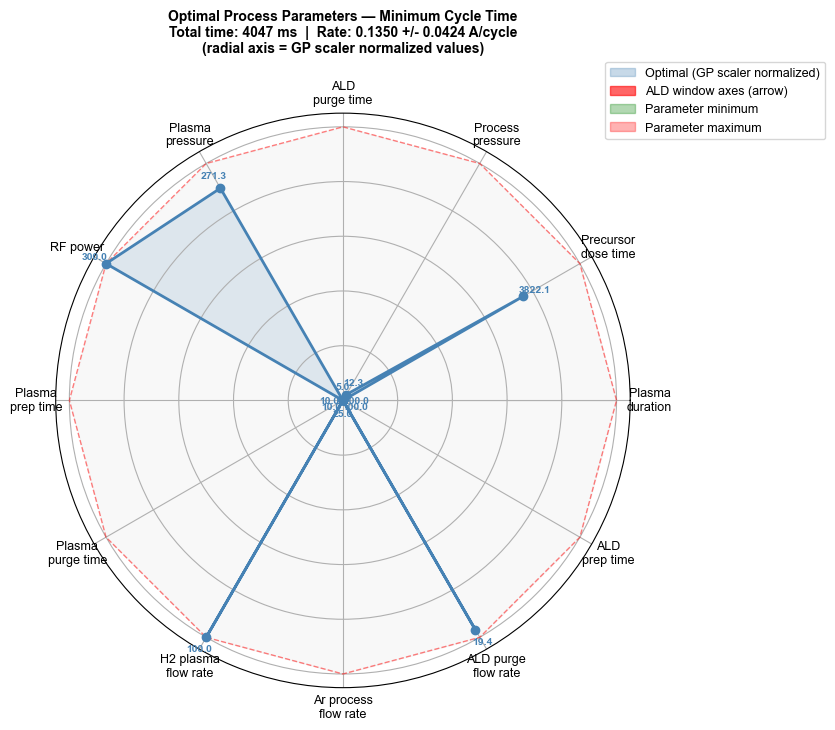

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

params   = config['modeled_params']
x_opt    = result.x        # same as opt_params in your code
f_opt    = f[0]            # already computed after your optimization
s_opt    = f_std[0]        # already computed after your optimization
ald_window_params = ['plasma_duration', 'precursor_dose_time']

# Normalize using the GP scaler — same scaling the model sees
df_opt        = pd.DataFrame([x_opt], columns=params)

# Also get min and max of scaled space for reference
df_min = pd.DataFrame([[bounds[i][0] for i in range(len(params))]], columns=params)
df_max = pd.DataFrame([[bounds[i][1] for i in range(len(params))]], columns=params)


x_opt_scaled  = gpmodel_final.scaler.transform(df_opt)[0]
x_min_scaled  = gpmodel_final.scaler.transform(df_min)[0]
x_max_scaled  = gpmodel_final.scaler.transform(df_max)[0]

print("Scaled parameter values at optimum:")
print(f"  {'Parameter':<25} {'Actual':>10} {'Scaled':>10} {'Scaled min':>12} {'Scaled max':>12}")
print("  " + "-" * 70)
for i, p in enumerate(params):
    print(f"  {p:<25} {x_opt[i]:>10.2f} {x_opt_scaled[i]:>10.4f} "
          f"{x_min_scaled[i]:>12.4f} {x_max_scaled[i]:>12.4f}")

# ── Spider plot ───────────────────────────────────────────────────────────────
labels_clean = [
    'Plasma\nduration',
    'Precursor\ndose time',
    'Process\npressure',
    'ALD\npurge time',
    'Plasma\npressure',
    'RF power',
    'Plasma\nprep time',
    'Plasma\npurge time',
    'H2 plasma\nflow rate',
    'Ar process\nflow rate',
    'ALD purge\nflow rate',
    'ALD\nprep time',
]

n_params = len(params)
angles   = np.linspace(0, 2 * np.pi, n_params, endpoint=False).tolist()
angles  += angles[:1]   # close polygon

values          = x_opt_scaled.tolist()     + [x_opt_scaled[0]]
values_min      = x_min_scaled.tolist()     + [x_min_scaled[0]]
values_max      = x_max_scaled.tolist()     + [x_max_scaled[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Draw parameter bounds as reference polygon
ax.plot(angles, values_max, lw=1, ls='--', color='red',   alpha=0.5, label='Parameter maximum')
ax.plot(angles, values_min, lw=1, ls='--', color='green', alpha=0.5, label='Parameter minimum')
ax.fill_between(angles, values_min, values_max, alpha=0.05, color='gray')

# Draw optimal point
ax.plot(angles, values, 'o-', lw=2, color='steelblue', ms=6, label='Optimal parameters')
ax.fill(angles, values, alpha=0.15, color='steelblue')

# Annotate each point with actual value
for i, (angle, scaled_val) in enumerate(zip(angles[:-1], x_opt_scaled)):
    actual_val = x_opt[i]
    ax.annotate(
        f'{actual_val:.1f}',
        xy=(angle, scaled_val),
        xytext=(angle, scaled_val + 0.05 * (values_max[i] - values_min[i])),
        ha='center', va='center',
        fontsize=7.5, color='steelblue', fontweight='bold',
    )

# Highlight ALD window axes
for param in ald_window_params:
    i     = params.index(param)
    angle = angles[i]
    ax.annotate('', xy=(angle, values_max[i] * 1.1),
                xytext=(angle, values_max[i] * 1.02),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_clean, fontsize=9)
ax.set_yticklabels([])

ald_patch = mpatches.Patch(color='red',      alpha=0.6, label='ALD window axes (arrow)')
opt_patch = mpatches.Patch(color='steelblue', alpha=0.3, label='Optimal (GP scaler normalized)')
min_patch = mpatches.Patch(color='green',    alpha=0.3, label='Parameter minimum')
max_patch = mpatches.Patch(color='red',      alpha=0.3, label='Parameter maximum')

ax.legend(handles=[opt_patch, ald_patch, min_patch, max_patch],
          loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

ax.set_title(
    f'Optimal Process Parameters — Minimum Cycle Time\n'
    f'Total time: {total_time(x_opt):.0f} ms  |  '
    f'Rate: {f_opt:.4f} +/- {s_opt:.4f} A/cycle\n'
    f'(radial axis = GP scaler normalized values)',
    fontsize=10, fontweight='bold', pad=20
)

plt.tight_layout()
# plt.savefig('ald_optimal_spider_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

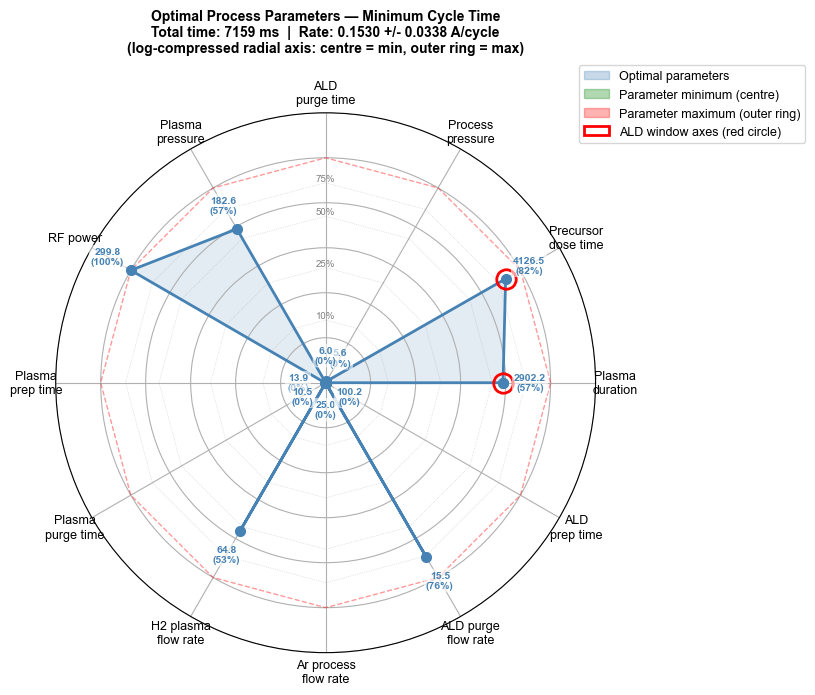


  Parameter                     Actual      Min      Max   % of range
  -----------------------------------------------------------------
  plasma_duration              2902.20    100.0   5000.0        57.2%
  precursor_dose_time          4126.53    100.0   5000.0        82.2%
  process_pressure                5.59      5.0    300.0         0.2%
  ALD_purge_time                  5.98      5.0   5000.0         0.0%
  plasma_pressure               182.58     25.0    300.0        57.3%
  RF_power_setpoint             299.79     25.0    300.0        99.9%
  plasma_prep_time               13.92     10.0   5000.0         0.1%
  plasma_purge_time              10.51     10.0  10000.0         0.0%
  H2_plasma_flow_rate            64.85     25.0    100.0        53.1%
  Ar_process_flow_rate           25.01     25.0     90.0         0.0%
  ALD_purge_flow_rate            15.48      1.0     20.0        76.2%
  ALD_prep_time                 100.24    100.0   4000.0         0.0%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

params            = config['modeled_params']
x_opt             = result.x
f_opt             = f[0]
s_opt             = f_std[0]
ald_window_params = ['plasma_duration', 'precursor_dose_time']

# Normalize each parameter to [0,1] within its own bounds
x_opt_norm_raw = np.array([
    (x_opt[i] - bounds[i][0]) / (bounds[i][1] - bounds[i][0])
    for i in range(len(params))
])

# Log compression — spreads out values near zero
# maps [0,1] -> [0,1] but with log scale
def log_compress(x):
    return np.log10(1 + 9 * np.clip(x, 0, 1))

x_opt_norm = log_compress(x_opt_norm_raw)

labels_clean = [
    'Plasma\nduration',
    'Precursor\ndose time',
    'Process\npressure',
    'ALD\npurge time',
    'Plasma\npressure',
    'RF power',
    'Plasma\nprep time',
    'Plasma\npurge time',
    'H2 plasma\nflow rate',
    'Ar process\nflow rate',
    'ALD purge\nflow rate',
    'ALD\nprep time',
]

n_params = len(params)
angles   = np.linspace(0, 2 * np.pi, n_params, endpoint=False).tolist()
angles  += angles[:1]

values = x_opt_norm.tolist() + [x_opt_norm[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Outer reference circle = parameter maximum
ax.plot(angles, [1.0] * len(angles),
        lw=1, ls='--', color='red', alpha=0.4, label='Parameter maximum')

# Inner reference circle = parameter minimum
ax.plot(angles, [0.0] * len(angles),
        lw=1, ls='--', color='green', alpha=0.4, label='Parameter minimum')

# Reference grid lines — positions in log-compressed space
# but labelled with the true % of parameter range
for true_pct, label in zip([0.10, 0.25, 0.50, 0.75],
                            ['10%', '25%', '50%', '75%']):
    r_log = log_compress(true_pct)
    ax.plot(angles, [r_log] * len(angles),
            color='gray', lw=0.5, ls=':', alpha=0.4)
    ax.text(np.pi / 2, r_log, label,
            ha='center', va='bottom', fontsize=7, color='gray')

# Draw optimal polygon
ax.plot(angles, values, 'o-', lw=2, color='steelblue', ms=7,
        label='Optimal parameters')
ax.fill(angles, values, alpha=0.15, color='steelblue')

# Annotate each vertex with actual value and TRUE % of range
for i, (angle, norm_val) in enumerate(zip(angles[:-1], x_opt_norm)):
    actual_val = x_opt[i]
    pct        = x_opt_norm_raw[i] * 100   # true % of range, not compressed

    r_text = norm_val + 0.12
    if r_text > 1.15:
        r_text = norm_val - 0.14

    ax.annotate(
        f'{actual_val:.1f}\n({pct:.0f}%)',
        xy=(angle, norm_val),
        xytext=(angle, r_text),
        ha='center', va='center',
        fontsize=7.5, color='steelblue', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
    )

# Highlight ALD window axes with a red marker ring
for param in ald_window_params:
    i     = params.index(param)
    angle = angles[i]
    norm  = x_opt_norm[i]
    ax.plot(angle, norm, 'o', ms=14, mfc='none', mec='red', mew=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_clean, fontsize=9)
ax.set_yticklabels([])
ax.set_ylim(0, 1.2)

opt_patch = mpatches.Patch(color='steelblue', alpha=0.3,
                            label='Optimal parameters')
min_patch = mpatches.Patch(color='green',     alpha=0.3,
                            label='Parameter minimum (centre)')
max_patch = mpatches.Patch(color='red',       alpha=0.3,
                            label='Parameter maximum (outer ring)')
ald_patch = mpatches.Circle((0, 0), radius=0.1, fc='none', ec='red', lw=2,
                             label='ALD window axes (red circle)')

ax.legend(handles=[opt_patch, min_patch, max_patch, ald_patch],
          loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

ax.set_title(
    f'Optimal Process Parameters — Minimum Cycle Time\n'
    f'Total time: {total_time(x_opt):.0f} ms  |  '
    f'Rate: {f_opt:.4f} +/- {s_opt:.4f} A/cycle\n'
    f'(log-compressed radial axis: centre = min, outer ring = max)',
    fontsize=10, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('ald_optimal_spider_log.png', dpi=150, bbox_inches='tight')
plt.show()

# Reference table with true % of range
print(f"\n  {'Parameter':<25} {'Actual':>10} {'Min':>8} {'Max':>8} {'% of range':>12}")
print("  " + "-" * 65)
for i, p in enumerate(params):
    lo, hi = bounds[i]
    pct    = x_opt_norm_raw[i] * 100
    print(f"  {p:<25} {x_opt[i]:>10.2f} {lo:>8.1f} {hi:>8.1f} {pct:>11.1f}%")

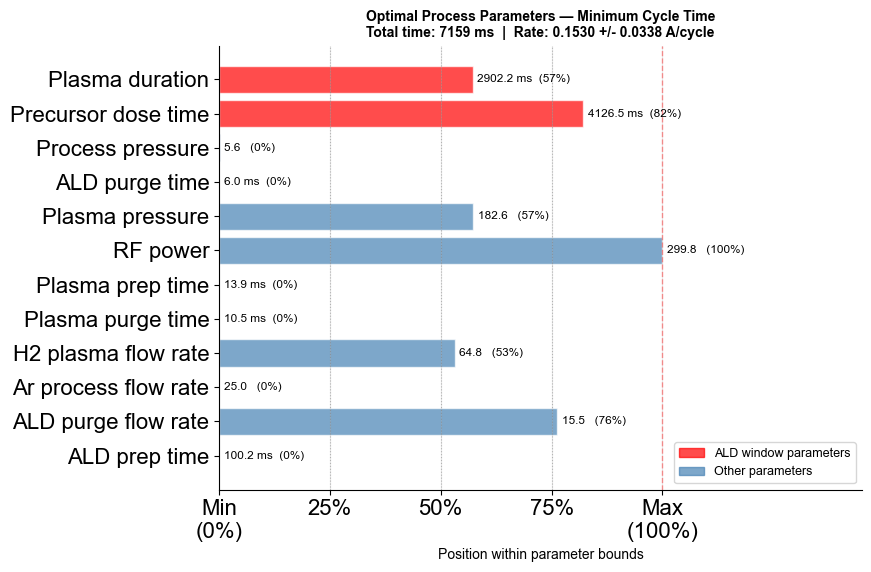

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

params            = config['modeled_params']
x_opt             = result.x
f_opt             = f[0]
s_opt             = f_std[0]
ald_window_params = ['plasma_duration', 'precursor_dose_time']

# Normalize to [0,1] within bounds
x_opt_norm = np.array([
    (x_opt[i] - bounds[i][0]) / (bounds[i][1] - bounds[i][0])
    for i in range(len(params))
])

labels_clean = [
    'Plasma duration',
    'Precursor dose time',
    'Process pressure',
    'ALD purge time',
    'Plasma pressure',
    'RF power',
    'Plasma prep time',
    'Plasma purge time',
    'H2 plasma flow rate',
    'Ar process flow rate',
    'ALD purge flow rate',
    'ALD prep time',
]

# Color: red for ALD window params, steelblue for the rest
colors = ['red' if p in ald_window_params else 'steelblue'
          for p in params]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(labels_clean, x_opt_norm, color=colors, alpha=0.7, edgecolor='white')

# Annotate with actual value and % of range
for i, (bar, norm_val) in enumerate(zip(bars, x_opt_norm)):
    actual_val = x_opt[i]
    pct        = norm_val * 100
    lo, hi     = bounds[i]
    unit       = 'ms' if params[i] in [
        'plasma_duration', 'precursor_dose_time', 'ALD_prep_time',
        'ALD_purge_time', 'plasma_prep_time', 'plasma_purge_time'
    ] else ''
    ax.text(
        norm_val + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{actual_val:.1f} {unit}  ({pct:.0f}%)',
        va='center', ha='left', fontsize=8.5, color='black'
    )

# Reference lines
ax.axvline(0.25, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(0.50, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(0.75, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(1.00, color='red',  ls='--', lw=1.0, alpha=0.4)

ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_xticklabels(['Min\n(0%)', '25%', '50%', '75%', 'Max\n(100%)'])
ax.set_xlim(0, 1.45)
ax.set_xlabel('Position within parameter bounds', fontsize=10)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='red',      alpha=0.7, label='ALD window parameters'),
    Patch(color='steelblue', alpha=0.7, label='Other parameters'),
], fontsize=9, loc='lower right')

ax.set_title(
    f'Optimal Process Parameters — Minimum Cycle Time\n'
    f'Total time: {total_time(x_opt):.0f} ms  |  '
    f'Rate: {f_opt:.4f} +/- {s_opt:.4f} A/cycle',
    fontsize=10, fontweight='bold'
)

ax.invert_yaxis()   # top-to-bottom order matches params list
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('ald_optimal_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Automatically identifying the ALD window

STAGE 2: Saturation Curves
  (low-SHAP time params held at MINIMUM — correct for min-time goal)
  ALD_prep_time            : fixed at 100 (minimum)
  ALD_purge_time           : fixed at 5 (minimum)
  plasma_prep_time         : fixed at 10 (minimum)
  plasma_purge_time        : fixed at 10 (minimum)

  plasma_duration:
    Plateau rate : 0.1763
    Onset        : 3946 s
    (These params give a REAL plateau within bounds)

  precursor_dose_time:
    Plateau rate : 0.1770
    Onset        : 4070 s
    (These params give a REAL plateau within bounds)


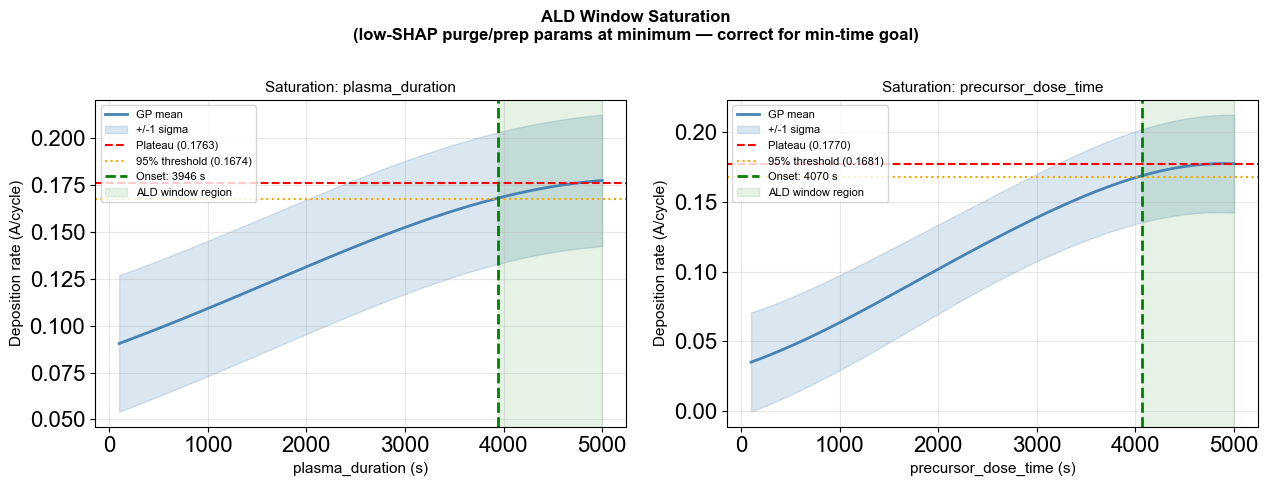


  r_max (global):          0.2913  (from Stage 1)
  r_plateau (ALD window):  0.1766  (from saturation curves)

  PREVIOUS (wrong)  MIN_RATE = 0.85 x r_max     = 0.2476  > plateau --> infeasible
  CORRECTED         MIN_RATE = 0.90 x r_plateau = 0.1590  < plateau --> feasible
  SAT_TOL (2% of plateau):   0.00353

STAGE 3: Minimum-Time ALD Window Optimization
  12D  |  3 constraints  |  MIN_RATE anchored to plateau
  plasma_duration: lower bound 100 -> 3946 s
  precursor_dose_time: lower bound 100 -> 4070 s
  ALD_prep_time: fixed at minimum 100 s (low SHAP)
  ALD_purge_time: fixed at minimum 5 s (low SHAP)
  plasma_prep_time: fixed at minimum 10 s (low SHAP)
  plasma_purge_time: fixed at minimum 10 s (low SHAP)

  3 constraints: 1 rate floor + 2 saturation

  Feasibility check (1000 random points)...
  Feasible: 12/1000 (1.2%)
differential_evolution step 1: f(x)= 8617.051308689188
differential_evolution step 2: f(x)= 8392.171677915374
differential_evolution step 3: f(x)= 8392.17167791537

In [ ]:
# Note: the optimal point may not look perfectly saturated in these 1D slices — the true test is that ALL saturating parameters are simultaneously self-limiting in the full 12D space, which we verified with the constraints.

from scipy.optimize import differential_evolution, NonlinearConstraint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

gpmodel_final = merged_df.at[merged_df.index[-1], 'gpmodel']
bounds  = [config['param_limits'][param] for param in config['modeled_params']]
params  = config['modeled_params']

def predict(x):
    df = pd.DataFrame([x], columns=params)
    f, f_std = gpmodel_final.posterior(df)
    return float(f[0]), float(f_std[0])

time_params  = ['plasma_duration', 'precursor_dose_time', 'ALD_prep_time',
                'ALD_purge_time',  'plasma_prep_time',    'plasma_purge_time']
time_indices = [params.index(p) for p in time_params]

def total_time(x):
    return sum(x[i] for i in time_indices)

# SHAP-informed classification
ald_window_params = ['plasma_duration', 'precursor_dose_time']
min_time_params   = ['ALD_prep_time', 'ALD_purge_time', 'plasma_prep_time', 'plasma_purge_time']

# ── Stage 2: Saturation sweep — low-SHAP params at MINIMUM ───────────────────
# This is intentional: we want the ALD window for minimum-time operation.
# Holding purge/prep at minimum while sweeping the two dose/plasma times
# gives the plateau that is actually achievable at low total process time.
print("=" * 65)
print("STAGE 2: Saturation Curves")
print("  (low-SHAP time params held at MINIMUM — correct for min-time goal)")
print("=" * 65)

# Build base vector: x_max chemistry, but min-time for low-SHAP params
x_base = x_max.copy()
for p in min_time_params:
    idx = params.index(p)
    x_base[idx] = bounds[idx][0]
    print(f"  {p:<25}: fixed at {bounds[idx][0]} (minimum)")

N_sweep = 80
onset_vals    = {}
plateau_rates = {}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, param in zip([ax1, ax2], ald_window_params):
    j      = params.index(param)
    lo, hi = bounds[j]
    sweep  = np.linspace(lo, hi, N_sweep)

    rates, stds = [], []
    for v in sweep:
        x = x_base.copy()
        x[j] = v
        f, s = predict(x)
        rates.append(f)
        stds.append(s)

    rates = np.array(rates)
    stds  = np.array(stds)

    # Plateau = mean of the top 10% of sweep values
    r_plateau = float(rates[-N_sweep // 10:].mean())
    threshold = 0.95 * r_plateau
    onset_idx = next((i for i, r in enumerate(rates) if r >= threshold), None)
    onset_val = float(sweep[onset_idx]) if onset_idx is not None else hi

    plateau_rates[param] = r_plateau
    onset_vals[param]    = onset_val

    ax.plot(sweep, rates, lw=2, color='steelblue', label='GP mean')
    ax.fill_between(sweep, rates - stds, rates + stds,
                    alpha=0.2, color='steelblue', label='+/-1 sigma')
    ax.axhline(r_plateau, color='red',    ls='--', lw=1.5,
               label=f'Plateau ({r_plateau:.4f})')
    ax.axhline(threshold, color='orange', ls=':',  lw=1.5,
               label=f'95% threshold ({threshold:.4f})')
    ax.axvline(onset_val, color='green',  ls='--', lw=2,
               label=f'Onset: {onset_val:.0f} s')
    ax.axvspan(onset_val, hi, alpha=0.1, color='green', label='ALD window region')
    ax.set_xlabel(f'{param} (s)', fontsize=11)
    ax.set_ylabel('Deposition rate (A/cycle)', fontsize=11)
    ax.set_title(f'Saturation: {param}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    print(f"\n  {param}:")
    print(f"    Plateau rate : {r_plateau:.4f}")
    print(f"    Onset        : {onset_val:.0f} s")
    print(f"    (These params give a REAL plateau within bounds)")

plt.suptitle(
    'ALD Window Saturation\n'
    '(low-SHAP purge/prep params at minimum — correct for min-time goal)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('ald_saturation_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

# ── The key numbers ───────────────────────────────────────────────────────────
r_plateau_mean = np.mean(list(plateau_rates.values()))

# THE FIX: anchor MIN_RATE and SAT_TOL to the PLATEAU, not the global max
# Previous error: MIN_RATE = 0.85 * r_max = 0.85 * 0.2913 = 0.2476 (above plateau!)
# Corrected:      MIN_RATE = 0.90 * r_plateau = 0.90 * 0.177  = 0.159  (feasible)
MIN_RATE   = 0.90 * r_plateau_mean
SAT_TOL    = 0.02 * r_plateau_mean
DELTA_FRAC = 0.10

print(f"\n  r_max (global):          {r_max:.4f}  (from Stage 1)")
print(f"  r_plateau (ALD window):  {r_plateau_mean:.4f}  (from saturation curves)")
print(f"\n  PREVIOUS (wrong)  MIN_RATE = 0.85 x r_max     = {0.85*r_max:.4f}  > plateau --> infeasible")
print(f"  CORRECTED         MIN_RATE = 0.90 x r_plateau = {MIN_RATE:.4f}  < plateau --> feasible")
print(f"  SAT_TOL (2% of plateau):   {SAT_TOL:.5f}")


# ── STAGE 3: Minimum-time optimization ───────────────────────────────────────
print("\n" + "=" * 65)
print("STAGE 3: Minimum-Time ALD Window Optimization")
print("  12D  |  3 constraints  |  MIN_RATE anchored to plateau")
print("=" * 65)

# Tighten lower bounds of ALD window params to their saturation onset
bounds_stage3 = list(bounds)
for param in ald_window_params:
    j = params.index(param)
    lo_old, hi = bounds[j]
    lo_new = onset_vals[param]
    bounds_stage3[j] = (lo_new, hi)
    print(f"  {param}: lower bound {lo_old} -> {lo_new:.0f} s")

# Fix low-SHAP time params at minimum by tightening both bounds to minimum
# This is equivalent to fixing them and removes 4 useless dimensions
for param in min_time_params:
    j = params.index(param)
    lo = bounds[j][0]
    bounds_stage3[j] = (lo, lo + 1)   # near-zero range forces optimizer to minimum
    print(f"  {param}: fixed at minimum {lo} s (low SHAP)")


# ── Constraint functions ──────────────────────────────────────────────────────

def con_min_rate(x):
    """Must be on the plateau — not trivially self-limiting near rate=0."""
    f, _ = predict(x)
    return f - MIN_RATE

def make_sat_con(j):
    """
    Self-limiting: increasing param j by DELTA_FRAC of its range
    must not change rate by more than SAT_TOL.
    """
    lo, hi = bounds_stage3[j]
    delta  = DELTA_FRAC * (hi - lo)
    def con(x):
        x_plus    = x.copy()
        x_plus[j] = min(x[j] + delta, hi)
        f_here, _ = predict(x)
        f_plus, _ = predict(x_plus)
        return SAT_TOL - abs(f_plus - f_here)
    return con

constraints = [NonlinearConstraint(con_min_rate, 0, np.inf)]
for param in ald_window_params:
    j = params.index(param)
    constraints.append(NonlinearConstraint(make_sat_con(j), 0, np.inf))

print(f"\n  {len(constraints)} constraints: 1 rate floor + {len(ald_window_params)} saturation")

# ── Feasibility check ─────────────────────────────────────────────────────────
print("\n  Feasibility check (1000 random points)...")
rng = np.random.default_rng(42)
feasible_pts = []
for _ in range(1000):
    x_try = np.array([rng.uniform(lo, hi) for lo, hi in bounds_stage3])
    c0 = con_min_rate(x_try)
    c1 = make_sat_con(params.index(ald_window_params[0]))(x_try)
    c2 = make_sat_con(params.index(ald_window_params[1]))(x_try)
    if c0 >= 0 and c1 >= 0 and c2 >= 0:
        feasible_pts.append(x_try)

print(f"  Feasible: {len(feasible_pts)}/1000 ({len(feasible_pts)/10:.1f}%)")

if len(feasible_pts) == 0:
    # Diagnostic: check each constraint independently
    print("\n  Diagnosing which constraint is still failing...")
    pass_c0 = pass_c1 = pass_c2 = 0
    rng2 = np.random.default_rng(42)
    for _ in range(1000):
        x_try = np.array([rng2.uniform(lo, hi) for lo, hi in bounds_stage3])
        if con_min_rate(x_try) >= 0:                                        pass_c0 += 1
        if make_sat_con(params.index(ald_window_params[0]))(x_try) >= 0:    pass_c1 += 1
        if make_sat_con(params.index(ald_window_params[1]))(x_try) >= 0:    pass_c2 += 1
    print(f"    Rate floor alone:              {pass_c0}/1000 pass")
    print(f"    Sat(plasma_duration) alone:    {pass_c1}/1000 pass")
    print(f"    Sat(precursor_dose_time) alone:{pass_c2}/1000 pass")
    print(f"\n    The failing constraint above tells you what to adjust:")
    print(f"    - Rate floor failing → lower MIN_RATE further")
    print(f"    - Saturation failing → increase SAT_TOL or DELTA_FRAC")
    raise RuntimeError("No feasible region found — see diagnostic above.")

# ── Run optimization ──────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='delta_grad',        category=UserWarning)
    warnings.filterwarnings('ignore', message='Singular Jacobian', category=UserWarning)

    result = differential_evolution(
        total_time,
        bounds=bounds_stage3,
        constraints=constraints,
        seed=42,
        maxiter=3000,
        popsize=25,
        mutation=(0.5, 1.5),
        recombination=0.7,
        init='sobol',
        polish=True,
        tol=1e-3,
        atol=1e-2,
        disp=True,
    )

# ── Results ───────────────────────────────────────────────────────────────────
x_opt        = result.x
f_opt, s_opt = predict(x_opt)

print(f"\nOptimizer: {'SUCCESS' if result.success else 'FAILED'} — {result.message}")
print(f"Rate floor:  {con_min_rate(x_opt):.4f}  "
      f"({'satisfied' if con_min_rate(x_opt) >= 0 else 'VIOLATED'})")

print("\nOptimal parameters:")
for p, v in zip(params, x_opt):
    lo, hi_orig = config['param_limits'][p]
    tag = ""
    if p in ald_window_params:  tag = "  [ALD window axis]"
    if p in min_time_params:    tag = "  [fixed at min — low SHAP]"
    if abs(v - lo) < 1:         tag += "  <- at lower bound"
    elif abs(v - config['param_limits'][p][1]) < 1: tag += "  <- at upper bound"
    print(f"  {p:<25}: {v:>8.2f}{tag}")

print(f"\nTotal process time:         {total_time(x_opt):.0f} s ({total_time(x_opt)/60:.1f} min)")
print(f"Expected rate:              {f_opt:.4f} +/- {s_opt:.4f}")
print(f"ALD window plateau rate:    {r_plateau_mean:.4f}")
print(f"Rate as % of plateau:       {100*f_opt/r_plateau_mean:.1f}%")
print(f"Rate as % of global max:    {100*f_opt/r_max:.1f}%")

# ── Self-limiting verification ─────────────────────────────────────────────────
print("\nSelf-limiting verification:")
for param in ald_window_params:
    j       = params.index(param)
    lo, hi  = bounds_stage3[j]
    delta   = DELTA_FRAC * (hi - lo)
    x_plus  = x_opt.copy()
    x_plus[j] = min(x_opt[j] + delta, hi)
    f_plus, _ = predict(x_plus)
    dr = abs(f_plus - f_opt)
    ok = dr < SAT_TOL
    print(f"  {param:<25}: delta_rate={dr:.5f}  SAT_TOL={SAT_TOL:.5f}  "
          f"{'self-limiting' if ok else 'NOT self-limiting'}")

if s_opt > 0.05 * r_plateau_mean:
    print(f"\nGP uncertainty (+/-{s_opt:.4f}) is significant relative to plateau.")
    print("  Validate these parameters experimentally before process use.")

In [ ]:
# Searching in all 12 parameters
from scipy.optimize import differential_evolution, NonlinearConstraint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

gpmodel_final = merged_df.at[merged_df.index[-1], 'gpmodel']
bounds  = [config['param_limits'][param] for param in config['modeled_params']]
params  = config['modeled_params']

def predict(x):
    df = pd.DataFrame([x], columns=params)
    f, f_std = gpmodel_final.posterior(df)
    return float(f[0]), float(f_std[0])

time_params  = ['plasma_duration', 'precursor_dose_time', 'ALD_prep_time',
                'ALD_purge_time',  'plasma_prep_time',    'plasma_purge_time']
time_indices = [params.index(p) for p in time_params]

def total_time(x):
    return sum(x[i] for i in time_indices)

ald_window_params = ['plasma_duration', 'precursor_dose_time']

# ── The three physical inputs — all explicitly justified ──────────────────────
#
# MIN_RATE_ABS:
#   The minimum deposition rate your process requires.
#   This is YOUR engineering requirement — not derived from the model.
#   Example: if you need at least 0.1 A/cycle to be useful, set 0.1.
#   This is the ONLY number you choose that is not purely about flatness.
#
# DELTA_FRAC:
#   How large a step to use when testing flatness.
#   "Increase the parameter by X% of its range and check if rate changes."
#   0.10 = 10% step. Matches a typical experimental step size.
#
# EPS_REL:
#   How flat is flat enough, relative to the current rate.
#   "Self-limiting means rate changes by less than X% when I increase dose."
#   0.05 = 5% relative change allowed.
#   This matches typical ALD experimental reproducibility (~2-5%).

MIN_RATE_ABS = 0.10   # A/cycle — YOUR process requirement
DELTA_FRAC   = 0.10   # 10% of parameter range
EPS_REL      = 0.05   # 5% relative rate change = self-limiting

print("=" * 65)
print("ALD Window Definition")
print("=" * 65)
print(f"""
  Self-limiting condition (from physics):
    |rate(x + delta) - rate(x)| / rate(x)  <  {EPS_REL}  ({EPS_REL*100:.0f}%)
    where delta = {DELTA_FRAC*100:.0f}% of the parameter range.

    This is PURELY a flatness criterion.
    No reference to r_max, no plateau assumption.
    A point is self-limiting if and only if the rate
    stops responding to more dose/plasma time.

  Minimum rate floor (from YOUR process requirement):
    rate(x)  >=  {MIN_RATE_ABS}  A/cycle
    
    This is the only number you choose.
    It is NOT derived from the model.
    It means: "I need at least this rate for the film to be useful."
    Without this, rate=0 is trivially self-limiting.

  Objective:
    Minimize total process time subject to both conditions above.
    The optimizer finds the ENTRY POINT to the ALD window —
    the shortest process that is self-limiting at a useful rate.
""")

# ── Constraints ───────────────────────────────────────────────────────────────

def con_min_rate(x):
    """Your process requirement — not model-derived."""
    f, _ = predict(x)
    return f - MIN_RATE_ABS

def make_sat_con(j):
    """
    Self-limiting condition for parameter j.
    Purely a flatness test — no reference to any global quantity.
    """
    lo, hi = bounds[j]
    delta  = DELTA_FRAC * (hi - lo)

    def con(x):
        f_here, _ = predict(x)
        if f_here < 1e-6:
            return -1.0   # rate is zero — trivially flat, reject
        x_plus      = x.copy()
        x_plus[j]   = min(x[j] + delta, hi)
        f_plus, _   = predict(x_plus)
        rel_change  = abs(f_plus - f_here) / f_here
        return EPS_REL - rel_change   # >= 0 means self-limiting

    return con

constraints = [
    NonlinearConstraint(con_min_rate, 0, np.inf),
    NonlinearConstraint(make_sat_con(params.index('plasma_duration')),     0, np.inf),
    NonlinearConstraint(make_sat_con(params.index('precursor_dose_time')), 0, np.inf),
]

# ── Feasibility check ─────────────────────────────────────────────────────────
print("=" * 65)
print("Feasibility check (2000 random points)")
print("=" * 65)

rng = np.random.default_rng(42)
feasible_pts = []
c0_pass = c1_pass = c2_pass = 0

for _ in range(2000):
    x_try = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
    c0 = con_min_rate(x_try) >= 0
    c1 = make_sat_con(params.index('plasma_duration'))(x_try) >= 0
    c2 = make_sat_con(params.index('precursor_dose_time'))(x_try) >= 0
    if c0: c0_pass += 1
    if c1: c1_pass += 1
    if c2: c2_pass += 1
    if c0 and c1 and c2:
        feasible_pts.append(x_try)

print(f"  Rate >= {MIN_RATE_ABS} alone:              {c0_pass}/2000 pass")
print(f"  Sat(plasma_duration) alone:         {c1_pass}/2000 pass")
print(f"  Sat(precursor_dose_time) alone:     {c2_pass}/2000 pass")
print(f"  All three together:                 {len(feasible_pts)}/2000 "
      f"({100*len(feasible_pts)/2000:.1f}%)")

if len(feasible_pts) == 0:
    print(f"""
  No feasible points found. One of two physical situations:

  (A) Rate floor too high:
      The GP never predicts a self-limiting rate above {MIN_RATE_ABS}.
      --> Lower MIN_RATE_ABS. Your process may not achieve that rate
          in the self-limiting regime with current data.

  (B) EPS_REL too strict OR bounds too narrow:
      The GP does not see saturation within current parameter bounds.
      --> Increase EPS_REL to 0.10, OR
      --> Collect experiments at longer plasma_duration / precursor_dose_time
          so the GP can learn where saturation occurs.
    """)
    raise RuntimeError("No feasible region. See diagnosis above.")

# ── Optimization ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Minimum-time optimization — full 12D, nothing fixed")
print("=" * 65)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='delta_grad',        category=UserWarning)
    warnings.filterwarnings('ignore', message='Singular Jacobian', category=UserWarning)

    result = differential_evolution(
        total_time,
        bounds=bounds,
        constraints=constraints,
        seed=42,
        maxiter=3000,
        popsize=25,
        mutation=(0.5, 1.5),
        recombination=0.7,
        init='sobol',
        polish=True,
        tol=1e-3,
        atol=1e-2,
        disp=True,
    )

# ── Results ───────────────────────────────────────────────────────────────────
x_opt        = result.x
f_opt, s_opt = predict(x_opt)

print(f"\nOptimizer: {'SUCCESS' if result.success else 'FAILED'} — {result.message}")

print("\nOptimal parameters:")
for p, v in zip(params, x_opt):
    lo, hi = config['param_limits'][p]
    tag = ""
    if p in ald_window_params: tag = "  [ALD window axis]"
    elif p in time_params:     tag = "  [time param]"
    if abs(v - lo) < 1:        tag += "  <- optimizer chose minimum"
    elif abs(v - hi) < 1:      tag += "  <- optimizer chose maximum"
    print(f"  {p:<25}: {v:>8.2f}{tag}")

print(f"\nTotal process time:      {total_time(x_opt):.0f} s "
      f"({total_time(x_opt)/60:.1f} min)")
print(f"Expected rate:           {f_opt:.4f} +/- {s_opt:.4f}")
print(f"Your rate requirement:   >= {MIN_RATE_ABS}")

# ── Self-limiting verification ────────────────────────────────────────────────
print(f"\nSelf-limiting verification:")
for param in ald_window_params:
    j      = params.index(param)
    lo, hi = bounds[j]
    delta  = DELTA_FRAC * (hi - lo)
    x_plus = x_opt.copy()
    x_plus[j] = min(x_opt[j] + delta, hi)
    f_plus, _ = predict(x_plus)
    rel_change = abs(f_plus - f_opt) / f_opt
    ok = rel_change < EPS_REL
    print(f"  {param:<25}: rel_change = {rel_change*100:.2f}%  "
          f"limit = {EPS_REL*100:.0f}%  "
          f"{'self-limiting' if ok else 'NOT self-limiting'}")

if s_opt > 0.5 * MIN_RATE_ABS:
    print(f"\nGP uncertainty (+/-{s_opt:.4f}) is large relative to your "
          f"rate requirement ({MIN_RATE_ABS}).")
    print("  Validate experimentally before process use.")


# Optimizer: SUCCESS — Optimization terminated successfully.

# Optimal parameters:
# plasma_duration          :   642.32  [ALD window axis]
# precursor_dose_time      :  4069.07  [ALD window axis]
# process_pressure         :     5.02  <- optimizer chose minimum
# ALD_purge_time           :     5.41  [time param]  <- optimizer chose minimum
# plasma_pressure          :   299.99  <- optimizer chose maximum
# RF_power_setpoint        :   299.96  <- optimizer chose maximum
# plasma_prep_time         :    11.08  [time param]
# plasma_purge_time        :    10.10  [time param]  <- optimizer chose minimum
# H2_plasma_flow_rate      :   100.00  <- optimizer chose maximum
# Ar_process_flow_rate     :    25.04  <- optimizer chose minimum
# ALD_purge_flow_rate      :    20.00  <- optimizer chose maximum
# ALD_prep_time            :   100.05  [time param]  <- optimizer chose minimum

# Total process time:      4838 s (80.6 min)
# Expected rate:           0.1176 +/- 0.0335
# Your rate requirement:   >= 0.1

# Self-limiting verification:
# plasma_duration          : rel_change = 5.00%  limit = 5%  self-limiting
# precursor_dose_time      : rel_change = 5.00%  limit = 5%  self-limiting

ALD Window Definition

  Self-limiting condition (from physics):
    |rate(x + delta) - rate(x)| / rate(x)  <  0.05  (5%)
    where delta = 10% of the parameter range.

    This is PURELY a flatness criterion.
    No reference to r_max, no plateau assumption.
    A point is self-limiting if and only if the rate
    stops responding to more dose/plasma time.

  Minimum rate floor (from YOUR process requirement):
    rate(x)  >=  0.1  A/cycle

    This is the only number you choose.
    It is NOT derived from the model.
    It means: "I need at least this rate for the film to be useful."
    Without this, rate=0 is trivially self-limiting.

  Objective:
    Minimize total process time subject to both conditions above.
    The optimizer finds the ENTRY POINT to the ALD window —
    the shortest process that is self-limiting at a useful rate.

Feasibility check (2000 random points)
  Rate >= 0.1 alone:              152/2000 pass
  Sat(plasma_duration) alone:         1236/2000 pass
  Sat(pr

In [ ]:
Optimal parameters:
  plasma_duration          :  3945.57  [ALD window axis]
  precursor_dose_time      :  4069.62  [ALD window axis]
  process_pressure         :    16.47
  ALD_purge_time           :     5.00  [fixed at min — low SHAP]  <- at lower bound
  plasma_pressure          :   121.03
  RF_power_setpoint        :   245.49
  plasma_prep_time         :    10.00  [fixed at min — low SHAP]  <- at lower bound
  plasma_purge_time        :    10.00  [fixed at min — low SHAP]  <- at lower bound
  H2_plasma_flow_rate      :    54.45
  Ar_process_flow_rate     :    28.85
  ALD_purge_flow_rate      :    13.97
  ALD_prep_time            :   100.00  [fixed at min — low SHAP]  <- at lower bound

Total process time:         8140 s (135.7 min)
Expected rate:              0.1617 +/- 0.0331
ALD window plateau rate:    0.1766
Rate as % of plateau:       91.6%
Rate as % of global max:    55.5%



Optimal parameters:
  plasma_duration          :   642.32  [ALD window axis]
  precursor_dose_time      :  4069.07  [ALD window axis]
  process_pressure         :     5.02  <- optimizer chose minimum
  ALD_purge_time           :     5.41  [time param]  <- optimizer chose minimum
  plasma_pressure          :   299.99  <- optimizer chose maximum
  RF_power_setpoint        :   299.96  <- optimizer chose maximum
  plasma_prep_time         :    11.08  [time param]
  plasma_purge_time        :    10.10  [time param]  <- optimizer chose minimum
  H2_plasma_flow_rate      :   100.00  <- optimizer chose maximum
  Ar_process_flow_rate     :    25.04  <- optimizer chose minimum
  ALD_purge_flow_rate      :    20.00  <- optimizer chose maximum
  ALD_prep_time            :   100.05  [time param]  <- optimizer chose minimum

Total process time:      4838 s (80.6 min)
Expected rate:           0.1176 +/- 0.0335
Your rate requirement:   >= 0.1



# SHAP Analysis

In [ ]:
all_exp_data

,plasma_duration,precursor_dose_time,process_pressure,ALD_purge_time,plasma_pressure,RF_power_setpoint,plasma_prep_time,plasma_purge_time,H2_plasma_flow_rate,Ar_process_flow_rate,ALD_purge_flow_rate,ALD_prep_time,dep_rate_mean,campaign
0,4041,4195,203,2469,125,130,4812,2744,83,82,12,3596,0.073500,0026
1,921,4953,222,1558,96,297,2597,2295,72,68,11,1154,0.063986,0026
2,1295,1586,243,4236,167,275,3124,7432,37,47,15,649,0.000000,0026
3,805,3436,276,3604,143,294,699,930,51,88,12,1770,0.082992,0026
4,4099,4554,37,4206,281,100,2098,5224,92,37,19,238,0.153807,0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,3268,3199,47,3000,275,103,100,4165,55,33,1,1200,0.026700,0027
396,2988,2233,13,2279,223,276,2029,295,42,59,15,2440,0.073650,0027
397,890,2544,111,3654,44,59,3132,5050,39,28,7,723,0.040814,0027
398,3572,4200,27,372,200,191,4522,9026,81,64,7,2254,0.058179,0027


In [ ]:
gpmodel_final = merged_df.at[merged_df.index[-1],'gpmodel']

# For the campaigns with the 12 parameters, use all experimental data from both campaigns BO and Random
# if len(config['modeled_params']) ==12:
#     X_train_SHAP = gpmodel_final.scaler.transform(all_exp_data[config['modeled_params']])
#     y_train_SHAP = all_exp_data['dep_rate_mean'].values
# else:

def load_from_module_path(path):
    m,c = path.split(":")
    mod = importlib.import_module(m)
    C = getattr(mod, c)
    return mod, C

config = campaign['configs'][-1]
parameter_space_limits = []
for param in config['modeled_params']:
    parameter_space_limits.append(config['param_limits'][param])


X_train_SHAP = gpmodel_final.my_gpo.x_data
y_train_SHAP = gpmodel_final.my_gpo.y_data

y_train_SHAP.shape

(200,)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Test predictions: [0.0795685  0.0704077  0.00342319]
Shape: (3,)


  0%|          | 0/200 [00:00<?, ?it/s]

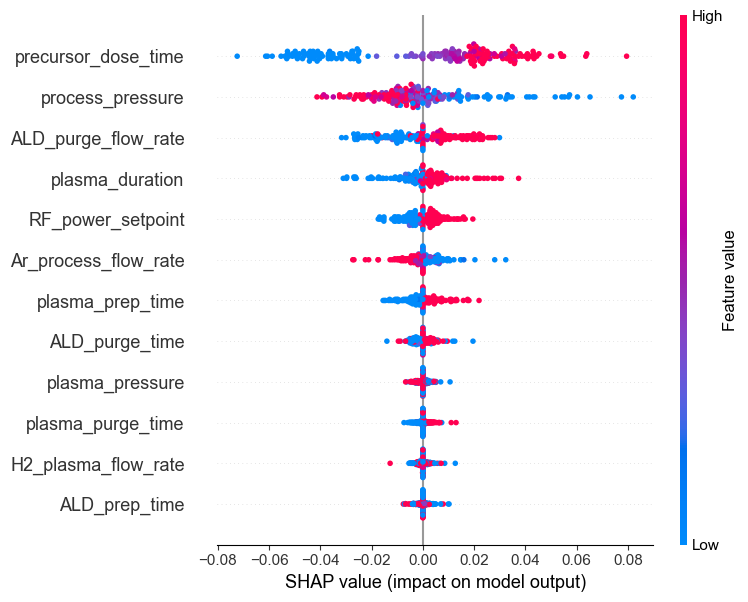

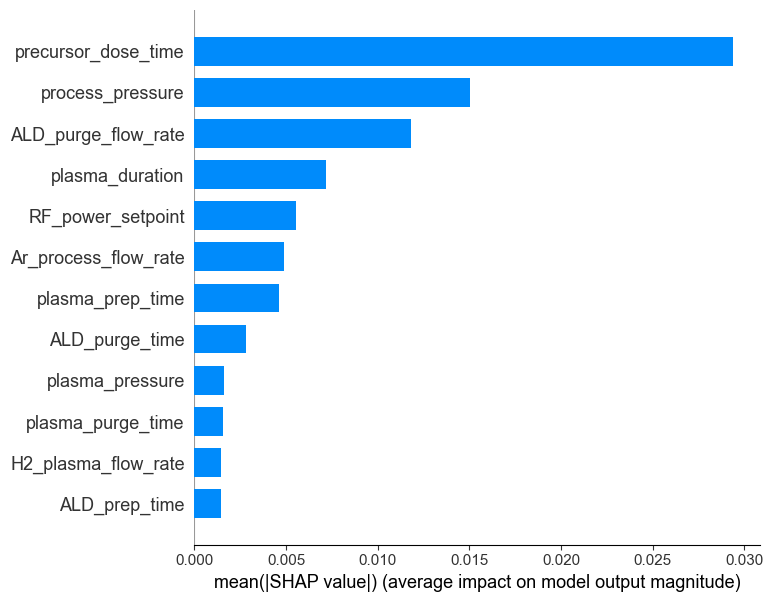

In [ ]:
# wrapping around the gpcam model
import numpy as np
import shap
import matplotlib.pyplot as plt

# ── Wrap the gpCAM posterior mean ─────────────────────────────────────────────
# KernelExplainer needs a function: array (n_samples, n_features) → array (n_samples,)
def gpcam_predict(X):
    X = np.array(X)  # SHAP sometimes passes pandas DataFrames or lists
    result = gpmodel_final.my_gpo.posterior_mean(X)
    return result["m(x)"]

# ── Quick sanity check before running SHAP ────────────────────────────────────
test_preds = gpcam_predict(X_train_SHAP[:3])
print("Test predictions:", test_preds)
print("Shape:", test_preds.shape)  # should be (3,)

# # ── SHAP explainer ────────────────────────────────────────────────────────────
explainer = shap.KernelExplainer(gpcam_predict, X_train_SHAP)

# nsamples controls accuracy vs speed — increase to 1024+ for final results
shap_values = explainer.shap_values(X_train_SHAP, nsamples=512)

# ── Feature names ─────────────────────────────────────────────────────────────
feature_names = [
    'plasma_duration', 'precursor_dose_time', 'process_pressure',
    'ALD_purge_time', 'plasma_pressure', 'RF_power_setpoint',
    'plasma_prep_time', 'plasma_purge_time', 'H2_plasma_flow_rate',
    'Ar_process_flow_rate', 'ALD_purge_flow_rate', 'ALD_prep_time'
]

# ── Plots ─────────────────────────────────────────────────────────────────────
# Beeswarm: shows distribution of SHAP values per feature
shap.summary_plot(shap_values, X_train_SHAP, feature_names=feature_names)

# Bar: global importance ranked by mean |SHAP|
shap.summary_plot(shap_values, X_train_SHAP, feature_names=feature_names, plot_type="bar")


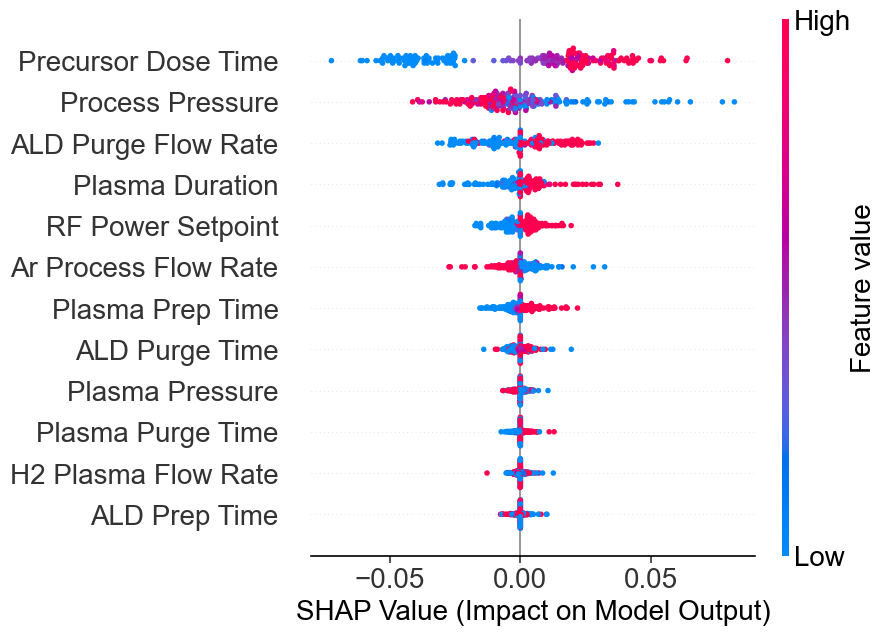

In [ ]:

# plt.figure()
# shap.summary_plot(
#     shap_values,
#     X_train_SHAP,
#     feature_names=feature_names,
#     show=False)

name_map = {
    "precursor_dose_time":   "Precursor Dose Time",
    "process_pressure":      "Process Pressure",
    "plasma_duration":       "Plasma Duration",
    "ALD_purge_flow_rate":   "ALD Purge Flow Rate",
    "Ar_process_flow_rate":  "Ar Process Flow Rate",
    "RF_power_setpoint":     "RF Power Setpoint",
    "plasma_prep_time":      "Plasma Prep Time",
    "ALD_purge_time":        "ALD Purge Time",
    "ALD_prep_time":         "ALD Prep Time",
    "plasma_pressure":       "Plasma Pressure",
    "plasma_purge_time":     "Plasma Purge Time",
    "H2_plasma_flow_rate":   "H2 Plasma Flow Rate"
}

formatted_feature_names = [name_map[f] for f in feature_names]

mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Arial'],
    'font.size':          13,
    'axes.labelsize':     15,
    'xtick.labelsize':    13,
    'ytick.labelsize':    14,
    'axes.linewidth':     1.2,
    'xtick.major.width':  1.2,
    'xtick.major.size':   5,
})

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_train_SHAP,
    feature_names=formatted_feature_names,
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP Value (Impact on Model Output)", fontsize=20)
ax.tick_params(axis='x', labelsize=20)  # ← x-axis ticks
ax.tick_params(axis='y', labelsize=20)  # ← y-axis feature names

fig = plt.gcf()
for ax_cb in fig.axes[1:]:
    ax_cb.tick_params(labelsize=20)        # ← "High" / "Low" labels
    ax_cb.yaxis.label.set_size(20)         # ← "Feature value" label

plt.savefig(
    f"/Users/MAlghalayini/Library/CloudStorage/GoogleDrive-malghalayini@lbl.gov/Shared drives/ALDbot/ALDBot Manuscripts/Manuscript 2 (Machine Learning)/Figures/SHAP Analysis/Campaign_{campaign_num}.pdf",
    dpi=300,
    bbox_inches="tight"
)